## Intro
Repo is at https://github.com/H-27/gpt-from-scratch
It contains the necessary files for execution, the zipped folder was too large to upload due to the created texts and outputs, but this file is dependant on them!

Neither of us needs this course in a specific module, it can be in any

Technical report file was put together from the seperate files, everything should be executable but copying errors might have happened

---
## Milestone 1: Data Preparation & BPE Segmenter
**Requirements**
- Train/Val/Test split of cleaned Shakespeare (≈1% test acceptable).
- Train BPE segmenter for multiple merge sizes `k`.
- Apply normalization (Laplace/add‑one) for n‑gram probabilities.
- Compare performance across `k` using perplexity (and optionally bpc).
- Provide an accuracy metric beyond perplexity (next‑token accuracy).

**Implemented Here**
- BPE artifacts: vocab & merges per k in `data/bpe_outputs/`.
- Encoded splits loaded in `NgramLM` constructor (cached token id files).
- Laplace smoothing in `get_ngram_prob_distribution` / `get_ngram_probs`.
- k sweep & plots: hyperparameter logging + plotting cells.
- Accuracy: `token_accuracy()` method + accuracy evaluation cell.

In [1]:
import nltk

text = "That U.S.A. poster-print costs $12.40..."

pattern = r"""(?x)
(                               # Outer capturing group for the full match
    (?:[A-Z]\.)+                # Abbreviations like U.S.A.
    | \w+(?:-\w+)* # Words with optional hyphens
    | \$?\d+(?:\.\d+)?%?        # Currency and percentages, e.g. $12.40, 82%
    | \.\.\.                    # Ellipsis
    | [\]\[.,;"'?():_\-`]       # Punctuation (escaped hyphen, backtick included)
)
"""

result = nltk.regexp_tokenize(text, pattern)
print(result)


['That', 'U.S.A.', 'poster-print', 'costs', '$12.40', '...']


# BPE Utility functions

In [ ]:
import re  # added for digit mapping
import string
from collections import defaultdict

from tqdm import tqdm

# Old train test split function
def split_text(text):
    text_len = len(text) # Get the length of the text
    part_size = text_len // 100
    train_size = (text_len - part_size) // 2
    train_set_1 = text[:train_size]
    test_set = text[train_size : train_size + part_size]
    train_set_2 = text[train_size + part_size :]
    train_set = train_set_1 + train_set_2
    return train_set, test_set

# Basic normalization function
def normalize_text(text, remove_punctuation=True):
    text = text.lower()  # Convert to lowercase
    text = " ".join(text.split())  # Remove extra spaces
    text = text.replace("\n", " ")  # Replace newlines with spaces
    if remove_punctuation:
        text = text.translate(
            str.maketrans("", "", string.punctuation)
        )  # Remove punctuation
    return text

# Advanced normalization function
def advanced_normalize(
    text: str,
    keep_sentence_final: bool = False,
    keep_apostrophes: bool = False,
    map_digits: bool = True,
) -> str:
    """Advanced normalization applying three optional strategies:
    1. Selective punctuation retention (keep .?! and/or apostrophes) while removing others.
    2. Quote / ellipsis normalization: fancy quotes -> ' or ", ellipsis … -> three dots.
    3. Digit mapping: map all digits 0-9 to 0 to reduce sparsity.

    Args:
        text: Raw input string.
        keep_sentence_final: Keep . ? ! if True.
        keep_apostrophes: Keep apostrophes (') if True.
        map_digits: Replace every digit with 0 if True.
    Returns:
        Normalized string.
    """
    # Normalize whitespace early (preserve baseline behavior order)
    text = text.replace("\n", " ")
    text = " ".join(text.split())
    # Lowercase (reuse baseline assumption)
    text = text.lower()

    # 2. Quote / ellipsis normalization before punctuation stripping
    replacements = {
        "“": '"',
        "”": '"',
        "„": '"',
        "′": "'",
        "’": "'",
        "‘": "'",
        "‛": "'",
        "…": "...",
    }
    text = "".join(replacements.get(ch, ch) for ch in text)

    # 1. Selective punctuation removal
    # Build punctuation set to remove
    allowed = set()
    if keep_sentence_final:
        allowed.update([".", "!", "?"])
    if keep_apostrophes:
        allowed.add("'")
    # Remove all other ASCII punctuation
    remove_chars = "".join(ch for ch in string.punctuation if ch not in allowed)
    if remove_chars:
        text = text.translate(str.maketrans("", "", remove_chars))

    # 3. Digit mapping
    if map_digits:
        text = re.sub(r"\d", "0", text)

    # Collapse whitespace again in case removals created doubles
    text = " ".join(text.split())
    return text

# Vocabulary update function
def update_vocab(vocab, addition):
    vocab.append(addition)
    return vocab

# Text preparation for BPE
def prep_text(text):
    words = text.split()
    new_text = []
    for word in words:
        word = word + "_"
        new_text.append(word)

    new_text = " ".join(new_text)
    new_text = list(new_text)
    return new_text

# Get the most frequent pair in the text
def get_max_pair(text, track_progress=True):
    pairs = defaultdict(int)
    if track_progress:
        pbar = tqdm(total=len(text) - 1, desc="Getting max pairs")
    # Count pairs
    for i in range(len(text) - 1):
        pair = text[i : i + 2] # Get the current pair
        pair = "".join(pair)
        # Increment the count for this pair
        if pair in pairs:
            pairs[pair] += 1
        else:
            pairs[pair] = 1
        if track_progress:
            pbar.update(1)

    # Find the most frequent pair
    most_frequent_pair = max(pairs, key=pairs.get)
    most_frequent_count = pairs[most_frequent_pair]
    return most_frequent_pair, most_frequent_count

# Update text by merging the most frequent pair
def update_text(text, substitute_pair, track_progress=False):
    i = 0
    new_text = []
    if track_progress:
        pbar = tqdm(total=len(text) - 1, desc="Updating text")
    # Merge pairs
    while i < len(text):
        # stop if at the last token
        if i == len(text) - 1:
            new_text.append(text[i])
            break
        # Get the current pair
        pair = text[i] + text[i + 1]
        # Increment the count for this pair
        if pair == substitute_pair:
            new_text.append(substitute_pair)
            i += 2  # Skip the next token as it was merged
            # Do not increment i, check for overlapping pairs
        else:
            new_text.append(text[i])
            i += 1
        if track_progress:
            pbar.update(1)
    # if new text is empty return the original text
    if new_text == []:
        return text
    # if new text is the same as the original text return the original text
    elif new_text == text:
        return text
    # else return new text
    else:
        return new_text

# Test vocabulary against new text
def test_vocab(text, vocab=None, k=2000):
    """Test the vocabulary against a new text."""
    # load vocab
    if vocab is None:
        vocab = open(f"data/bpe_outputs/vocab_with_k{k}.txt", "r").read()
    print(f"Testing with vocabulary of size {len(vocab.splitlines())}")
    # prepare text
    text = normalize_text(text)
    words = text.split()
    tokens = 0
    unknown_tokens = []

    for word in words:
        word = word + "_"
        i = 0
        while i < len(word):
            found_token = False
            # Try to find longest matching token
            for j in range(len(word), i, -1):
                if word[i:j] in vocab:
                    tokens += 1
                    i = j
                    found_token = True
                    break
                else:
                    tokens += 1
                    unknown_tokens.append(word[i:j])
                    i = j
            if not found_token:
                unknown_tokens.append(word[i])
                i += 1
                tokens += 1

    coverage = (tokens - len(unknown_tokens)) / tokens * 100

    return coverage, unknown_tokens

# Get token counts from vocab in corpus
def get_token_counts(vocab, corpus):
    counted_vocab = defaultdict(int)
    for token in vocab.splitlines():
        counted_vocab[token] = corpus.count(token)
    return counted_vocab

# Reprocess corpus with given vocab
def reprocess_corpus(corpus, vocab):
    """
    Reprocess the corpus to create a vocabulary of size k.
    Args:
        corpus (str): The input text.
        k (int): The desired vocabulary size.
    Returns:
        str: The processed text with the vocabulary of size k.
    """
    corpus = normalize_text(corpus)
    corpus = list(corpus.replace(" ", "_"))
    for token in vocab.splitlines():
        if len(token) < 2:
            continue
        else:
            update_text(corpus, token, track_progress=False)
    pass


# BPE run file

In [ ]:
import string

from tqdm import tqdm


def perform_bpe(
    text="data/corpora/shakespeare.txt",
    k=2000,
    normalization=None,
    track_progress=False,
    save_to=None,
):
    k_start = k
    if save_to == None:
        save_to = f"data/bpe_outputs/vocab_with_k{k_start}.txt"
    # Load and normalize the text
    text = open(text, "r").read()
    if normalization == "advanced":
        text = advanced_normalize(text)
    else:
        text = normalize_text(text)

    # Split the text into training and test sets
    text = list(text.replace(" ", "_"))

    # Create the initial vocabulary
    vocab = list(string.ascii_lowercase) + ["_"]

    pbar = tqdm(total=k, desc="Merging pairs")

    while k > 0:
        # Get the most frequent pair in the text
        if track_progress:
            print("Getting most frequent pair...")
        most_frequent_pair, count = get_max_pair(text, track_progress)

        # If no pairs found, break
        if count < 2:
            break

        # Replace the most frequent pair in the text
        if track_progress:
            print("Updating text with most frequent pair...")
        text = update_text(text, most_frequent_pair, track_progress)

        # Add the new token to the vocabulary
        vocab.append(most_frequent_pair)

        k -= 1
        pbar.update(1)

    with open(save_to, "w", encoding="utf-8") as f:
        for token in vocab:
            f.write(token + "\n")
    # Derive merges (Option B: tokens length > 1)
    merges = [t for t in vocab if len(t) > 1]
    merges_path = save_to.replace("vocab_with_k", "merges_k")
    with open(merges_path, "w", encoding="utf-8") as mf:
        for m in merges:
            mf.write(m + "\n")
    print(f"Vocabulary saved to {save_to} (merges derived -> {merges_path})")
    return save_to


if __name__ == "__main__":
    track_progress = False
    text = open("data/corpora/shakespeare.txt", "r").read()
    text = normalize_text(text)

    train, test = split_text(text)
    # train = train[:100000]
    text = list(train.replace(" ", "_"))
    vocab = list(string.ascii_lowercase) + ["_"]
    k = 1000
    k_start = k

    pbar = tqdm(total=k, desc="Merging pairs")

    while k > 0:
        # Get the most frequent pair in the text
        if track_progress:
            print("Getting most frequent pair...")
        most_frequent_pair, count = get_max_pair(text, track_progress)
        # If no pairs found, break
        if count < 2:
            break

        # Replace the most frequent pair in the text
        if track_progress:
            print("Updating text with most frequent pair...")
        text = update_text(text, most_frequent_pair, track_progress)
        # Add the new token to the vocabulary
        vocab.append(most_frequent_pair)

        k -= 1
        pbar.update(1)

    print("Vocabulary done, saving...")
    # Save the vocabulary to a file
    with open(f"data/bpe_outputs/vocab_with_k{k_start}.txt", "w") as f:
        for token in vocab:
            f.write(token + "\n")
    print("Vocabulary saved.")


# BPE Test

Using 'clean' version of Shakespeare text.
Training text file: data/corpora/Shakespeare_clean_train.txt
Validation text file: data/corpora/Shakespeare_clean_valid.txt
Advanced flag: False (vocab files will have suffix '')
BPE Vocabulary Coverage Test

--- Testing with k=50 ---
Using existing vocabulary file: data/bpe_outputs/vocab_with_k50.txt

Testing Shakespeare Validation:
Testing with vocabulary of size 77
  Coverage: 69.08%
  Unknown tokens (first 10): ['hath_', 'person_', 'smooth_', 'dispose_', 'be_', 'suspected_', 'framed_', 'make_', 'women_', 'false_']
  Total unknown tokens: 15472

Testing In Mr. Knox's Country:
Testing with vocabulary of size 77
  Coverage: 70.17%
  Unknown tokens (first 10): ['project_', 'gutenberg_', 'ebook_', 'mr_', 'knoxs_', 'country_', 'this_', 'ebook_', 'for_', 'use_']
  Total unknown tokens: 52309

Testing A Room with a View:
Testing with vocabulary of size 77
  Coverage: 69.34%
  Unknown tokens (first 10): ['project_', 'gutenberg_', 'ebook_', 'room_',

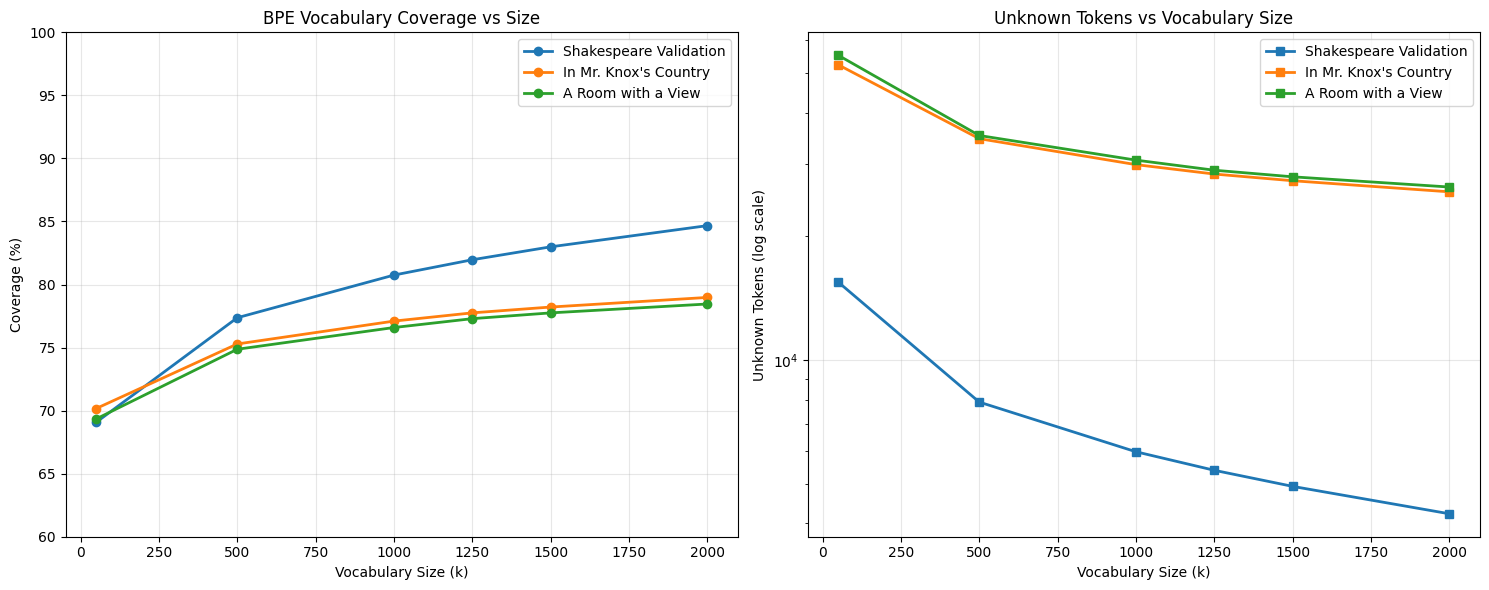


Test complete!


In [3]:
import os

from src.tokenizer.bpe import perform_bpe
from src.tokenizer.bpe_utils import split_text, test_vocab

try:
    import matplotlib.pyplot as plt

    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    print("Matplotlib not available. Visualization will be skipped.")

# --- Added flag for advanced normalization run naming ---
ADVANCED = False  # Set True when using advanced normalization pipeline
ADV_SUFFIX = "_adv" if ADVANCED else ""


def visualize_coverage_results(results):
    """Create visualizations for BPE vocabulary coverage results."""
    if not HAS_MATPLOTLIB:
        print("Matplotlib not available. Skipping visualization.")
        return

    k_values = list(results.keys())
    text_names = list(results[k_values[0]].keys())

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Coverage vs Vocabulary Size
    for text_name in text_names:
        coverages = [results[k][text_name]["coverage"] for k in k_values]
        ax1.plot(k_values, coverages, marker="o", linewidth=2, label=text_name)

    ax1.set_xlabel("Vocabulary Size (k)")
    ax1.set_ylabel("Coverage (%)")
    ax1.set_title("BPE Vocabulary Coverage vs Size")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(60, 100)

    # Plot 2: Unknown Tokens vs Vocabulary Size (log scale)
    for text_name in text_names:
        unknown_counts = [results[k][text_name]["unknown_count"] for k in k_values]
        ax2.plot(k_values, unknown_counts, marker="s", linewidth=2, label=text_name)

    ax2.set_xlabel("Vocabulary Size (k)")
    ax2.set_ylabel("Unknown Tokens (log scale)")
    ax2.set_title("Unknown Tokens vs Vocabulary Size")
    ax2.set_yscale("log")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        "data/bpe_outputs/bpe_coverage_analysis.png", dpi=300, bbox_inches="tight"
    )
    plt.show()


def print_coverage_summary(results):
    """Print a formatted summary table of coverage results."""
    k_values = list(results.keys())
    text_names = list(results[k_values[0]].keys())

    print("\n" + "=" * 80)
    print("COVERAGE SUMMARY TABLE")
    print("=" * 80)
    print(
        f"{'Vocab Size':<12} {'Shakespeare':<15} {'Knox Country':<15} {'Room w/ View':<15}"
    )
    print("-" * 80)

    for k in k_values:
        row = f"{k:<12}"
        for text_name in text_names:
            coverage = results[k][text_name]["coverage"]
            row += f"{coverage:>10.1f}%    "
        print(row)


if __name__ == "__main__":
    # Test different vocabulary sizes
    k_values = [50, 500, 1000, 1250, 1500, 2000]
    version = "clean"  # Choose between "clean" or "dirty" or empty string "" for original text

    # Set up file paths based on version
    if version == "clean":
        train_text = "data/corpora/Shakespeare_clean_train.txt"
        val_text = "data/corpora/Shakespeare_clean_valid.txt"
    elif version == "dirty":
        train_text = "data/corpora/shakespeare_dirty_train.txt"
        val_text = "data/corpora/shakespeare_dirty_valid.txt"
    else:
        # Load and normalize the text
        text = open("data/corpora/shakespeare.txt", "r").read()
        train_text, val_text = split_text(text)

    # Print which version  and files are being used
    print(f"Using '{version}' version of Shakespeare text.")
    print(f"Training text file: {train_text}")
    print(f"Validation text file: {val_text}")
    print(f"Advanced flag: {ADVANCED} (vocab files will have suffix '{ADV_SUFFIX}')")

    # Test texts to evaluate vocabulary coverage
    test_texts = [
        ("Shakespeare Validation", val_text),
        ("In Mr. Knox's Country", "data/corpora/In Mr. Knox's Country.txt"),
        ("A Room with a View", "data/corpora/A Room with a View.txt"),
    ]

    print("=" * 60)
    print("BPE Vocabulary Coverage Test")
    print("=" * 60)

    # Store results for visualization
    coverage_results = {k: {} for k in k_values}

    for k in k_values:
        print(f"\n--- Testing with k={k} ---")

        vocab_filename = f"data/bpe_outputs/vocab_with_k{k}{ADV_SUFFIX}.txt"
        # Check if vocabulary exists, create if not
        if os.path.exists(vocab_filename):
            print(f"Using existing vocabulary file: {vocab_filename}")
            vocab_location = vocab_filename
        else:
            print(f"Running BPE tokenizer for k={k} (creating {vocab_filename})...")
            vocab_location = perform_bpe(
                text=train_text,
                k=k,
                track_progress=False,
                save_to=vocab_filename,
            )

        # Test vocabulary on different texts
        for text_name, text_path in test_texts:
            print(f"\nTesting {text_name}:")

            if text_name == "Shakespeare Validation":
                text_content = open(text_path, "r", encoding="utf-8").read()
            else:
                text_content = open(text_path, "r", encoding="utf-8").read()

            vocab_content = open(vocab_location, "r", encoding="utf-8").read()

            coverage, unknown_tokens = test_vocab(
                text_content, vocab=vocab_content, k=k
            )
            print(f"  Coverage: {coverage:.2f}%")
            if len(unknown_tokens) > 0:
                print(f"  Unknown tokens (first 10): {list(unknown_tokens)[:10]}")
                print(f"  Total unknown tokens: {len(unknown_tokens)}")

            coverage_results[k][text_name] = {
                "coverage": coverage,
                "unknown_count": len(unknown_tokens),
            }

    print_coverage_summary(coverage_results)
    visualize_coverage_results(coverage_results)

    print("\n" + "=" * 60)
    print("Test complete!")


---
## Milestone 2: Classical n‑gram Models (n = 1..4)
**Requirements**
- Flexible `n` (unigram → 4‑gram).
- Intrinsic evaluation: perplexity on validation/test for each n.
- For bigram: examine effect of varying `k`.
- Smoothing: Laplace (add‑one).
- Simple interpolation (or backoff) supported.
- Extrinsic evaluation: generation (context → next tokens) with argmax and sampling; EOS termination.

**Implemented Here**
- Variable order via `NgramLM.n`.
- Perplexity computation in `NgramLM.evaluate`.
- Bigram k effect: covered by k sweep results.
- Interpolation: `get_interpolated_probability` and λ sweep plot cell.
- Generation: `NgramLM.generate` (temperature, top‑k, sampling/argmax, EOS) + extrinsic comparison cell.

# Ngram Utils

In [ ]:
import json
import math
import re
from collections import defaultdict

from tqdm import tqdm

from src.tokenizer import bpe_utils

# Pattern: sentence end punctuation (., ?, !) not part of an ellipsis (triple or more dots)
SENT_SPLIT_PATTERN = re.compile(r"(?<!\.)[.?!]+(?!\.)\s+|(?<!\.)[.?!]+(?!\.)$")


def load_ngrams_and_contexts(n, k, suffix=""):
    """
    Load n-grams and contexts from cached JSON files.
    Args:
        n (int): The 'n' of the n-gram model.
        k (int): The 'k' used in BPE vocabulary size.
    Returns:
        tuple: (ngrams, contexts) where both are defaultdict(int)
    """
    ngram_file = f"data/ngram_outputs/ngrams_n{n}_k{k}{suffix}.json"
    context_file = f"data/ngram_outputs/contexts_n{n}_k{k}{suffix}.json"
    with open(ngram_file, "r") as f:
        ngrams_dict = json.load(f)
        # Convert string keys back to tuples
        ngrams = defaultdict(int)
        for key, value in ngrams_dict.items():
            ngrams[tuple(eval(key))] = value

    with open(context_file, "r") as f:
        contexts_dict = json.load(f)
        # Convert string keys back to tuples
        contexts = defaultdict(int)
        for key, value in contexts_dict.items():
            contexts[tuple(eval(key))] = value
    return ngrams, contexts


def load_vocab(n: int, k: int, suffix: str):
    vocab = open(f"data/bpe_outputs/vocab_k{k}{suffix}.txt", "r").read().splitlines()
    return vocab


def merge_tokens_ranked(tokens, merges):
    """
    Merge tokens based on a ranked list of merges.

    Args:
        tokens (list[str]): Current token sequence (typically chars + '_').
        merges (list[str]): Ordered merges (earlier means higher priority).
    Returns:
        list[str]: Tokens after applying all possible merges.
    """
    # Build quick lookup: token -> rank
    ranked = {m: r for r, m in enumerate(merges) if len(m) > 1}
    if not ranked:
        return tokens
    max_len = max(len(m) for m in ranked)

    while True:
        best = None  # (rank, start_index, span_len, merged_token)
        tlen = len(tokens)
        # Brute-force scan of all spans up to max_len
        for i in range(tlen):
            # Remaining length check
            remaining = tlen - i
            if remaining < 2:
                break
            limit = min(max_len, remaining)
            for span_len in range(2, limit + 1):
                candidate = "".join(tokens[i : i + span_len])
                if candidate in ranked:
                    cand_rank = ranked[candidate]
                    if best is None or cand_rank < best[0]:
                        best = (cand_rank, i, span_len, candidate)
        if best is None:
            break
        _, i, span_len, merged = best
        tokens = tokens[:i] + [merged] + tokens[i + span_len :]
    return tokens


def apply_bpe(corpus, merges, track_progress=False):
    """
    Apply Byte Pair Encoding (BPE) to the given corpus using the provided merges.
    Ellipses ("...") are preserved inside sentences (not treated as boundary).

    Args:
        corpus (str): The input text corpus.
        merges (list): The BPE merges to apply.
        track_progress (bool): Whether to show a progress bar.

    Returns:
        list: A list of processed sentences, each represented as a list of tokens.
    """
    # Regex split (same as above) to ensure consistent sentence boundaries
    sentences = re.split(SENT_SPLIT_PATTERN, corpus.strip())
    processed_sentences = []
    if track_progress:
        pbar = tqdm(total=len(sentences), desc="Applying BPE to sentences")
    for sentence in sentences:
        if not sentence.strip():
            if track_progress:
                pbar.update(1)
            continue
        sentence = bpe_utils.advanced_normalize(sentence)
        sentence = list(sentence.replace(" ", "_"))
        sentence = merge_tokens_ranked(sentence, merges)
        sentence.insert(0, "<s>")  # Append start of sentence token
        sentence.append("</s>")  # Append end of sentence token
        processed_sentences.append(sentence)
        if track_progress:
            pbar.update(1)

    return processed_sentences


def create_ngrams(sentences, n, track_progress=False):
    """
    Create n-grams from the given sentences.
    Uses window size from n down to 1 for backoff.
    Args:
        sentences (list of list of str): List of sentences, where each sentence is a list of tokens.
        n (int): The 'n' in n-grams, indicating the size of the n-grams to create.
        track_progress (bool): Whether to display a progress bar.
    Returns:
        tuple: A tuple containing two defaultdicts:
    """
    ngrams = defaultdict(int)
    contexts = defaultdict(int)
    if track_progress:
        pbar = tqdm(total=len(sentences) - 1, desc="Creating ngrams")
    for sentence in sentences:
        window_size = n  # start with n and decrease to 1 for backoff
        sentence_length = len(sentence)
        while window_size > 0:
            for i in range(sentence_length - window_size + 1):
                ngram = tuple(sentence[i : i + window_size])
                context = tuple(sentence[i : i + window_size - 1])
                ngrams[ngram] += 1
                contexts[context] += 1
            window_size -= 1
        if track_progress:
            pbar.update(1)

    return ngrams, contexts

# Calculate n-gram probability with add-one smoothing
def get_ngram_prob(ngram, vocab, ngrams, contexts):
    context = ngram[:-1]
    ngram_count = ngrams.get(ngram, 0)
    context_count = contexts.get(context, 0)

    # Add-one smoothing
    return (ngram_count + 1) / (context_count + len(vocab))

# Given a context, get the most probable next word
def get_word_from_context(context, vocab, ngrams, contexts):
    # Get all possible next words
    # possible next words as defaultdict with word as key and probability as value
    possible_next_words = {}

    # Find all ngrams that match the context
    # --- IGNORE ---
    # Later updated to iterate through vocab to improve performance
    for ngram in ngrams:
        if len(ngram) == len(context) + 1 and ngram[:-1] == context:
            possible_next_word = ngram[-1]
            next_word_prob = get_ngram_prob(ngram, vocab, ngrams, contexts)
            possible_next_words[possible_next_word] = next_word_prob

    if not possible_next_words:
        return None, 0


def get_unigram_probs(self, k, suffix=""):
    # load ngrams and contexts from file
    ngrams, contexts = self.load_ngrams_and_contexts(1, k, suffix)
    vocab = self.load_vocab(1, k, suffix)

    # only get ngrams of length 1
    unigrams = {key: value for key, value in ngrams.items() if len(key) == 1}
    total_count = sum(unigrams.values())
    # Add-one smoothing for unigrams
    unigram_probs = {
        key: (count + 1) / (total_count + len(vocab)) for key, count in unigrams.items()
    }
    return unigram_probs

# Calculate n-gram probability with add-one smoothing
def calculate_ngram_probability(ngram, n, k, suffix=""):
    # if unigram
    if n == 1:
        return get_unigram_probs(ngram, k, suffix)
    # load ngrams and contexts from file
    ngrams, contexts = load_ngrams_and_contexts(n, k, suffix)
    vocab = load_vocab(n, k, suffix)

    context = ngram[:-1]
    ngram_count = ngrams.get(ngram, 0)
    context_count = contexts.get(context, 0)

    # Add-one smoothing
    return (ngram_count + 1) / (context_count + len(vocab))

# Calculate perplexity of the model on a given set of sentences
def calculate_perplexity(sentences, n, ngrams, contexts, vocab_size):
    """
    Calculates the perplexity of a model on a given set of sentences.

    Args:
        sentences (list of list of str): The test/validation sentences.
        n (int): The 'n' of the n-gram model.
        ngrams (defaultdict): A dictionary with n-gram counts from training.
        contexts (defaultdict): A dictionary with context counts from training.
        vocab_size (int): The size of the vocabulary from training.

    Returns:
        float: The perplexity.
    """
    total_log_prob = 0
    total_tokens = 0

    for sentence in sentences:
        # We evaluate on n-grams, so we need to count them
        total_tokens += len(sentence) - (n - 1)
        for i in range(len(sentence) - n + 1):
            ngram = tuple(sentence[i : i + n])
            prob = calculate_ngram_probability(ngram, ngrams, contexts, vocab_size)
            total_log_prob += -math.log(prob)

    if total_tokens == 0:
        return float("inf")  # Avoid division by zero

    avg_log_prob = total_log_prob / total_tokens
    perplexity = math.exp(avg_log_prob)
    return perplexity

# Generate the next word using argmax with backoff
def generate_next_word(context, ngrams, contexts, vocab_size, n):
    """
    Generates the next word based on the given context using argmax.
    Implements a backoff strategy if the context is not found.

    Args:
        context (tuple): The current context (n-1 gram).
        ngrams (defaultdict): A dictionary with n-gram counts.
        contexts (defaultdict): A dictionary with context counts.
        vocab_size (int): The size of the vocabulary.
        n (int): The 'n' of the n-gram model.

    Returns:
        str: The predicted next word.
    """
    possible_next_words = []
    for ngram in ngrams:
        if len(ngram) == len(context) + 1 and ngram[:-1] == context:
            possible_next_words.append(ngram[-1])

    if not possible_next_words:
        # Backoff to a shorter context
        if len(context) > 1:
            return generate_next_word(context[1:], ngrams, contexts, vocab_size, n)
        else:
            # Backoff to unigrams - find the most frequent unigram
            unigrams = {k: v for k, v in ngrams.items() if len(k) == 1}
            if not unigrams:
                return "</s>"  # Should not happen if vocab is not empty
            # find the most likely unigram that is not a start token
            best_unigram = max(
                (ug for ug in unigrams if ug != ("<s>",)),
                key=unigrams.get,
                default=None,
            )
            return best_unigram[0] if best_unigram else "</s>"

    best_word = None
    max_prob = -1

    for word in possible_next_words:
        ngram = context + (word,)
        prob = calculate_ngram_probability(ngram, ngrams, contexts, vocab_size)
        if prob > max_prob:
            max_prob = prob
            best_word = word

    return best_word

# Generate a sentence given a starting context
def generate_sentence(start_context, n, ngrams, contexts, vocab_size, max_length=20):
    """
    Generates a sentence starting with a given context.

    Args:
        start_context (list): A list of words to start the sentence.
        n (int): The 'n' of the n-gram model.
        ngrams (defaultdict): A dictionary with n-gram counts.
        contexts (defaultdict): A dictionary with context counts.
        vocab_size (int): The size of the vocabulary.
        max_length (int): The maximum length of the generated sentence.

    Returns:
        list: The generated sentence as a list of tokens.
    """
    sentence = list(start_context)
    # Make sure context is n-1
    current_context = (
        tuple(sentence[-(n - 1) :]) if len(sentence) >= n - 1 else tuple(sentence)
    )

    for _ in range(max_length):
        next_word = generate_next_word(current_context, ngrams, contexts, vocab_size, n)
        if next_word == "</s>" or not next_word:
            break
        sentence.append(next_word)
        current_context = tuple(sentence[-(n - 1) :])

    return sentence


# Ngram Engine Class

In [5]:
import json
import re
from collections import defaultdict

import numpy as np
from tqdm import tqdm

from src.ngram_engine.nge_utils import apply_bpe
from src.tokenizer import bpe_utils


class NgramEngine:
    def __init__(self, n, k, advanced=False):
        self.n = n
        self.k = k
        self.adv_suffix = "_adv" if advanced else ""
        self.vocab = (
            open(f"data/bpe_outputs/vocab_with_k{k}{self.adv_suffix}.txt", "r")
            .read()
            .splitlines()
        )
        self.vocab_size = len(self.vocab)
        self.merge_rules = (
            open(f"data/bpe_outputs/merges_k{k}{self.adv_suffix}.txt", "r")
            .read()
            .splitlines()
        )
        self.ngrams, self.contexts = self.load_ngrams_and_contexts(
            n, k, self.adv_suffix
        )
        self.SENT_SPLIT_PATTERN = re.compile(
            r"(?<!\.)[.?!]+(?!\.)\s+|(?<!\.)[.?!]+(?!\.)$"
        )

    def load_ngrams_and_contexts(self, n, k, suffix=""):
        """
        Load n-grams and contexts from cached JSON files.
        Args:
            n (int): The 'n' of the n-gram model.
            k (int): The 'k' used in BPE vocabulary size.
        Returns:
            tuple: (ngrams, contexts) where both are defaultdict(int)
        """
        ngram_file = f"data/ngram_outputs/ngrams_n{n}_k{k}{suffix}.json"
        context_file = f"data/ngram_outputs/contexts_n{n}_k{k}{suffix}.json"
        with open(ngram_file, "r") as f:
            ngrams_dict = json.load(f)
            # Convert string keys back to tuples
            ngrams = defaultdict(int)
            for key, value in ngrams_dict.items():
                ngrams[tuple(eval(key))] = value

        with open(context_file, "r") as f:
            contexts_dict = json.load(f)
            # Convert string keys back to tuples
            contexts = defaultdict(int)
            for key, value in contexts_dict.items():
                contexts[tuple(eval(key))] = value
        return ngrams, contexts

    def load_vocab(self, n: int, k: int, suffix: str):
        vocab = (
            open(f"data/bpe_outputs/vocab_with_k{k}{suffix}.txt", "r")
            .read()
            .splitlines()
        )
        return vocab

    def merge_tokens_ranked(self, tokens, merges):
        """
        Merge tokens based on a ranked list of merges.

        Args:
            tokens (list[str]): Current token sequence (typically chars + '_').
            merges (list[str]): Ordered merges (earlier means higher priority).
        Returns:
            list[str]: Tokens after applying all possible merges.
        """
        # Build quick lookup: token -> rank
        ranked = {m: r for r, m in enumerate(merges) if len(m) > 1}
        if not ranked:
            return tokens
        max_len = max(len(m) for m in ranked)

        while True:
            best = None  # (rank, start_index, span_len, merged_token)
            tlen = len(tokens)
            # Brute-force scan of all spans up to max_len
            for i in range(tlen):
                # Remaining length check
                remaining = tlen - i
                if remaining < 2:
                    break
                limit = min(max_len, remaining)
                for span_len in range(2, limit + 1):
                    candidate = "".join(tokens[i : i + span_len])
                    if candidate in ranked:
                        cand_rank = ranked[candidate]
                        if best is None or cand_rank < best[0]:
                            best = (cand_rank, i, span_len, candidate)
            if best is None:
                break
            _, i, span_len, merged = best
            tokens = tokens[:i] + [merged] + tokens[i + span_len :]
        return tokens

    def apply_bpe(self, corpus, merges, track_progress=False):
        """
        Apply Byte Pair Encoding (BPE) to the given corpus using the provided merges.
        Ellipses ("...") are preserved inside sentences (not treated as boundary).

        Args:
            corpus (str): The input text corpus.
            merges (list): The BPE merges to apply.
            track_progress (bool): Whether to show a progress bar.

        Returns:
            list: A list of processed sentences, each represented as a list of tokens.
        """
        # Regex split (same as above) to ensure consistent sentence boundaries
        sentences = re.split(self.SENT_SPLIT_PATTERN, corpus.strip())
        processed_sentences = []
        if track_progress:
            pbar = tqdm(total=len(sentences), desc="Applying BPE to sentences")
        for sentence in sentences:
            if not sentence.strip():
                if track_progress:
                    pbar.update(1)
                continue
            sentence = bpe_utils.normalize_text(sentence)
            sentence = list(sentence.replace(" ", "_"))
            sentence = self.merge_tokens_ranked(sentence, merges)
            sentence.insert(0, "<s>")  # Append start of sentence token
            sentence.append("</s>")  # Append end of sentence token
            processed_sentences.append(sentence)
            if track_progress:
                pbar.update(1)

        return processed_sentences

    def create_ngrams(sentences, n, track_progress=False):
        """
        Create n-grams from the given sentences.
        Uses window size from n down to 1 for backoff.
        Args:
            sentences (list of list of str): List of sentences, where each sentence is a list of tokens.
            n (int): The 'n' in n-grams, indicating the size of the n-grams to create.
            track_progress (bool): Whether to display a progress bar.
        Returns:
            tuple: A tuple containing two defaultdicts:
        """
        ngrams = defaultdict(int)
        contexts = defaultdict(int)
        if track_progress:
            pbar = tqdm(total=len(sentences) - 1, desc="Creating ngrams")
        for sentence in sentences:
            window_size = n  # start with n and decrease to 1 for backoff
            sentence_length = len(sentence)
            while window_size > 0:
                for i in range(sentence_length - window_size + 1):
                    ngram = tuple(sentence[i : i + window_size])
                    context = tuple(sentence[i : i + window_size - 1])
                    ngrams[ngram] += 1
                    contexts[context] += 1
                window_size -= 1
            if track_progress:
                pbar.update(1)

        return ngrams, contexts

    def get_unigram_probs(self):
        # Extract unigrams from existing ngrams data (should always exist since ngrams contains 1 to n)
        vocab = self.vocab

        # Get all ngrams of length 1 from existing data
        unigrams = {key: value for key, value in self.ngrams.items() if len(key) == 1}
        total_count = sum(unigrams.values())

        # Add-one smoothing for unigrams
        # Convert tuple keys to single tokens
        unigram_probs = {
            key[0]: (count + 1) / (total_count + len(vocab))
            for key, count in unigrams.items()
        }
        return unigram_probs

    def get_ngram_probs(self, ngram, n):
        # if unigram
        if n == 1:
            return self.get_unigram_probs()
        # load ngrams and contexts from file
        ngrams, contexts = self.ngrams, self.contexts

        context = ngram[:-1]
        ngram_count = ngrams.get(ngram, 0)
        context_count = contexts.get(context, 0)

        # Add-one smoothing
        return (ngram_count + 1) / (context_count + self.vocab_size)

    def get_word_from_context(self, context, n):
        # load ngrams and contexts from file

        # Get all possible next words
        possible_next_words = {}
        while len(possible_next_words) == 0 and n > 1:
            backoff_weight = pow(0.4, self.n - n)  # backoff weight
            # if context is empty, use unigram
            if len(context) == 0:
                unigrams_and_probs = self.get_unigram_probs()
                for tok, p in unigrams_and_probs.items():
                    possible_next_words[tok] = p * backoff_weight
            # find all ngrams that match the context
            for token in self.vocab:
                ngram = context + (token,)
                next_word_probs = self.get_ngram_probs(ngram, n) * backoff_weight
                possible_next_words[token] = next_word_probs
            # if no possible next word probability is above the threshold, backoff to n-1 gram
            if not possible_next_words:
                n -= 1
                context = context[-(n - 1) :]
        # draw a word based on the probabilities
        if possible_next_words:
            words = list(possible_next_words.keys())  # Remove the [0] indexing
            probs = list(possible_next_words.values())
            # This converts the scores into a probability distribution
            total_prob = sum(probs)
            if total_prob == 0:
                unigram_probs = self.get_unigram_probs()
                if not unigram_probs:
                    return "</s>"  # Should not happen
                # Get the unigram with the highest probability
                best_unigram = max(unigram_probs, key=unigram_probs.get)
                return best_unigram  # Remove the [0] indexing
            probs = [p / total_prob for p in probs]
            return np.random.choice(words, p=probs)
        return None

    def generate_sentence(self, start_context, max_length=20):
        """
        Generates a sentence starting with a given context.
        """
        sentence = list(start_context)
        n = self.n

        for _ in range(max_length):
            context = tuple(sentence[-(n - 1) :])
            next_word = self.get_word_from_context(context, n)

            if next_word == "</s>" or next_word is None:
                break
            sentence.append(next_word)

        return sentence

    def get_probs_from_context(self, context, n):
        # Get all possible next words
        possible_next_words = {}
        while len(possible_next_words) == 0 and n > 1:
            backoff_weight = pow(0.4, self.n - n)  # backoff weight
            # if context is empty, use unigram
            if len(context) == 0:
                unigrams_and_probs = self.get_unigram_probs()
                for tok, p in unigrams_and_probs.items():
                    possible_next_words[tok] = p * backoff_weight
            # find all ngrams that match the context
            for token in self.vocab:
                ngram = context + (token,)
                next_word_probs = self.get_ngram_probs(ngram, n) * backoff_weight
                possible_next_words[token] = next_word_probs
            # if no possible next word probability is above the threshold, backoff to n-1 gram
            if not possible_next_words:
                n -= 1
                context = context[-(n - 1) :]
        # draw a word based on the probabilities
        if possible_next_words:
            words = list(possible_next_words.keys())  # Remove the [0] indexing
            probs = list(possible_next_words.values())
            # This converts the scores into a probability distribution
            total_prob = sum(probs)
            if total_prob == 0:
                unigram_probs = self.get_unigram_probs()
                if not unigram_probs:
                    return "</s>"  # Should not happen
                # Get the unigram with the highest probability
                best_unigram = max(unigram_probs, key=unigram_probs.get)
                return best_unigram  # Remove the [0] indexing
            probs = [p / total_prob for p in probs]
            return words, probs
        return None, 0

    def calculate_perplexity(self):
        # load validation files
        text = open("data/corpora/Shakespeare_clean_valid.txt", "r").read()
        sentences = apply_bpe(text, self.merge_rules, track_progress=True)
        total_log_prob = 0.0
        total_tokens = 0
        pbar = tqdm(total=len(sentences) - 1, desc="Calculating Perplexity")

        for sentence in sentences:
            sentence_length = len(sentence)
            # Extract n-grams from the sentence
            for i in range(sentence_length - self.n + 1):
                ngram = tuple(sentence[i : i + self.n])
                context = ngram[:-1]
                target = ngram[-1]

                # Get probability distribution using backoff
                predictions, probs = self.get_probs_from_context(context, self.n)

                # Find probability of target token
                if predictions and target in predictions:
                    target_idx = predictions.index(target)
                    target_prob = probs[target_idx]
                else:
                    # If target not found, use a very small probability (smoothing fallback)
                    target_prob = 1e-10

                total_log_prob += np.log(target_prob)
                total_tokens += 1
            pbar.update(1)

        # Calculate perplexity: exp(-1/N * sum(log p(w_i)))
        perplexity = (
            np.exp(-total_log_prob / total_tokens) if total_tokens > 0 else float("inf")
        )

        print(f"Validation perplexity: {perplexity:.2f}")
        print(f"Total tokens evaluated: {total_tokens}")

        return perplexity


# Ngram Run

In [11]:
import json
import os
from collections import defaultdict

from src.ngram_engine.ngram import NgramEngine
from src.tokenizer import bpe

from src.ngram_engine.nge_utils import apply_bpe, create_ngrams

if __name__ == "__main__":
    # Grid definitions (original single values replaced by lists)
    n_values = [3]
    k_values = [50]
    adv_values = [True]

    os.makedirs("data/ngram_outputs", exist_ok=True)
    results_file = "data/ngram_outputs/perplexity_grid.jsonl"
    existing = set()
    results = []
    # Load existing results (do not duplicate)
    if os.path.exists(results_file):
        with open(results_file, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json.loads(line)
                    key = (obj.get("n"), obj.get("k"), bool(obj.get("advanced")))
                    existing.add(key)
                    results.append(obj)
                except Exception:
                    pass

    first_demo_done = False  # keep original sample generation only once

    for advanced in adv_values:
        for k in k_values:
            for n in n_values:
                key = (n, k, advanced)
                if key in existing:
                    # Already computed
                    continue
                adv_suffix = "_adv" if advanced else ""
                # load vocab / merges
                merges_path = f"data/bpe_outputs/merges_k{k}{adv_suffix}.txt"
                if not os.path.exists(merges_path):
                    print(f"Warning: merges file {merges_path} not found, creating...")
                    bpe.perform_bpe(
                        text="data/corpora/Shakespeare_clean_train.txt",
                        k=k,
                        normalization=adv_suffix.replace("_adv", "advanced"),
                        track_progress=False,
                        save_to=f"data/bpe_outputs/vocab_with_k{k}{adv_suffix}.txt",
                    )

                merge_rules = open(merges_path, "r").read().splitlines()
                text = open("data/corpora/Shakespeare_clean_train.txt", "r").read()
                # sentences cache (include adv suffix to distinguish)
                sentences_path = f"data/ngram_outputs/sentences_k{k}{adv_suffix}.txt"
                try:
                    with open(sentences_path, "r") as f:
                        sentences = [line.strip().split() for line in f.readlines()]
                except FileNotFoundError:
                    sentences = apply_bpe(text, merge_rules, track_progress=False)
                    with open(sentences_path, "w") as f:
                        for sentence in sentences:
                            f.write(" ".join(sentence) + "\n")
                # ngram/context cache paths
                ngram_file = f"data/ngram_outputs/ngrams_n{n}_k{k}{adv_suffix}.json"
                context_file = f"data/ngram_outputs/contexts_n{n}_k{k}{adv_suffix}.json"
                try:
                    with open(ngram_file, "r") as f:
                        ngrams_dict = json.load(f)
                        ngrams = defaultdict(int)
                        for tkey, val in ngrams_dict.items():
                            ngrams[tuple(eval(tkey))] = val
                    with open(context_file, "r") as f:
                        contexts_dict = json.load(f)
                        contexts = defaultdict(int)
                        for tkey, val in contexts_dict.items():
                            contexts[tuple(eval(tkey))] = val
                except FileNotFoundError:
                    ngrams, contexts = create_ngrams(sentences, n)
                    ngrams_dict = {str(key2): value2 for key2, value2 in ngrams.items()}
                    contexts_dict = {
                        str(key2): value2 for key2, value2 in contexts.items()
                    }
                    with open(ngram_file, "w") as f:
                        json.dump(ngrams_dict, f)
                    with open(context_file, "w") as f:
                        json.dump(contexts_dict, f)
                # Engine
                engine = NgramEngine(n=n, k=k, advanced=advanced)
                # One-time demo (reuse original logic at first n=3 occurrence if available)
                if not first_demo_done and n == 3:
                    first_demo_done = True
                    print("\nSample n-grams:")
                    sample_ngrams = list(engine.ngrams.items())[:1]
                    my_text = "The world is so small"
                    my_text_bpe = engine.apply_bpe(my_text, merge_rules)[0]
                    d = -n
                    my_text_bpe = my_text_bpe[:-1]
                    sample_ngrams.append((tuple(my_text_bpe[d:]), 1))
                    for ng_ex, count in sample_ngrams:
                        print(f"  {ng_ex}: {count}")
                        sentence = engine.generate_sentence(ng_ex)
                        sentence_str = (
                            " ".join(sentence)
                            .replace("<s>", "")
                            .replace("</s>", ".")
                            .replace(" ", "")
                            .replace("_", " ")
                            .strip()
                        )
                        ng_disp = " ".join(ng_ex).replace("_", " ")
                        sentence_str = " ".join(sentence_str.split())
                        print(f" Generated sentence: {ng_disp} -> {sentence_str}")
                # Perplexity
                ppl = engine.calculate_perplexity()
                rec = {
                    "n": n,
                    "k": k,
                    "advanced": advanced,
                    "perplexity": round(float(ppl), 4),
                }
                with open(results_file, "a") as rf:
                    rf.write(json.dumps(rec) + "\n")
                existing.add(key)
                results.append(rec)
                print(
                    f"n={n} k={k} adv={int(advanced)} perplexity={rec['perplexity']} (saved)"
                )



# Brief code using engine generation for extrinsic evaluation

In [10]:
from src.ngram_engine.ngram import NgramEngine

# Use n=3, k=2000, advanced=False for this example (adjust as needed)
engine = NgramEngine(n=3, k=2000, advanced=False)

# Pick a random context from unknown_tokens (strip trailing underscore)
context_token = unknown_tokens[0].rstrip("_")
context = [context_token]

# Generate a sentence using the engine
generated = engine.generate_sentence(context, max_length=20)
generated_text = " ".join(generated).replace("_", " ").replace("<s>", "").replace("</s>", "").strip()
print(f"Context: {context_token}\nGenerated: {generated_text}")

Context: project
Generated: project another  i do  through  in your  eld  would lady macbeth  sing  prithee  ets  jessica  pe fal men  iti gh  ther  sleep  if you  llo


# Engine Perplexity Results


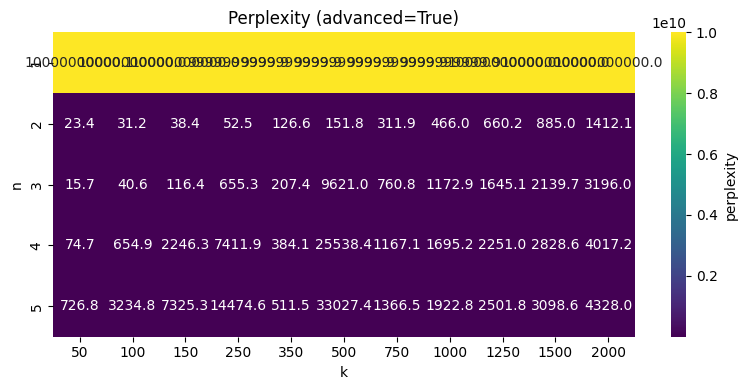

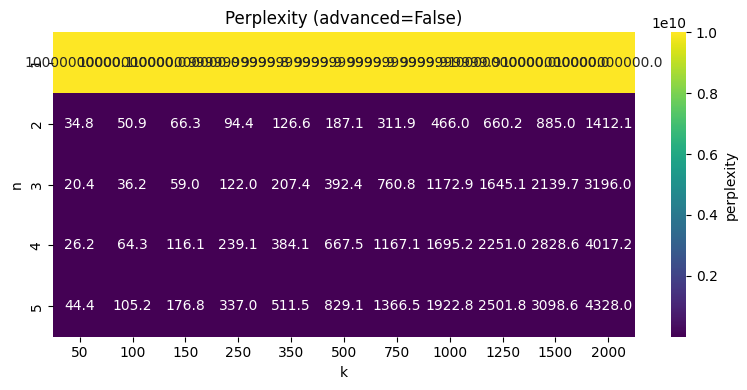

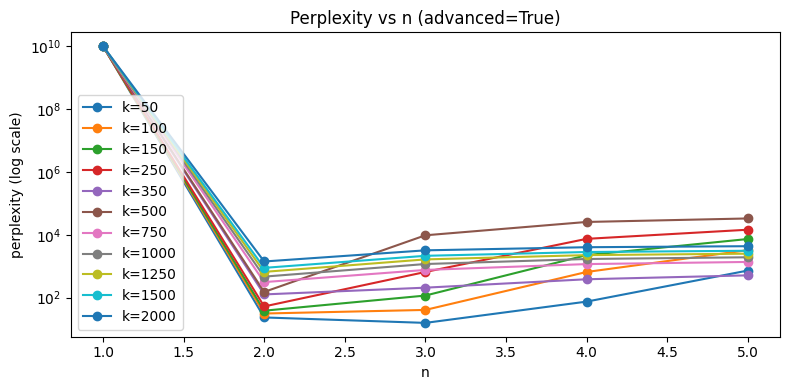

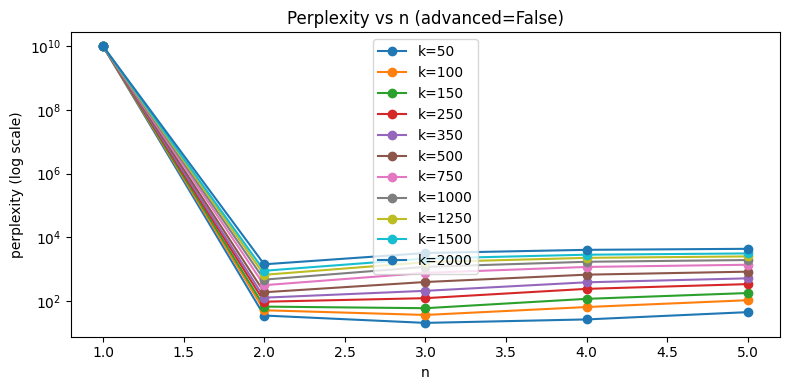

In [8]:
import json, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

def load_perplexity_grid(path="data/ngram_outputs/perplexity_grid.jsonl"):
    rows=[]
    with open(path,"r") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def plot_perplexity_grid(df, advanced=True):
    sub = df[df.advanced==advanced]
    pivot = sub.pivot(index="n", columns="k", values="perplexity")
    plt.figure(figsize=(8,4))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="viridis", cbar_kws={'label':'perplexity'})
    plt.title(f"Perplexity (advanced={advanced})")
    plt.ylabel("n")
    plt.xlabel("k")
    plt.tight_layout()

def plot_lines(df, advanced=True):
    sub = df[df.advanced==advanced]
    plt.figure(figsize=(8,4))
    for k, grp in sub.groupby("k"):
        plt.plot(grp.n, grp.perplexity, marker="o", label=f"k={k}")
    plt.yscale("log")
    plt.xlabel("n"); plt.ylabel("perplexity (log scale)")
    plt.title(f"Perplexity vs n (advanced={advanced})")
    plt.legend()
    plt.tight_layout()

df = load_perplexity_grid()
plot_perplexity_grid(df, advanced=True)
plot_perplexity_grid(df, advanced=False)
plot_lines(df, advanced=True)
plot_lines(df, advanced=False)
plt.show()

---
## Milestone 3: Neural Embedding n‑gram Model
**Requirements**
- Neural (embedding + feed‑forward) language model variant.
- Early stopping with patience; save top checkpoints.
- Hyperparameter searches (individually) over: k, learning rate, hidden dimension, interpolation weight λ.
- Optional alternate optimizer usage.
- Record validation metrics (loss, perplexity) per epoch.

**Implemented Here**
- Neural variant: `NgramLM` with `lam=1.0` (pure neural) using embeddings + linear layers.
- Early stopping utility: `train_with_early_stopping` (patience & best checkpoint retention).
- Hyperparameter sweeps & logs: dedicated search scripts + JSONL + plotting cells.
- Optimizers: Adam (default) and SGD selectable.

# Neural Ngram Utils

In [13]:
import csv
import json
import os
from typing import Any, Dict, List, Optional, Tuple

import torch

from src.ngram_engine.nge_utils import apply_bpe


def ensure_dir(path: str):
    """Create directory if it does not exist."""
    os.makedirs(path, exist_ok=True)


def append_run_result(
    results_csv: str,
    config: Dict[str, Any],
    best_val_loss: float,
    best_val_ppl: Optional[float],
    history_len: int,
):
    """Append a single run summary (config + best metrics) to a CSV file.
    Creates the file with a header if missing.
    """
    ensure_dir(os.path.dirname(results_csv) or ".")
    header = list(config.keys()) + ["best_val_loss", "best_val_ppl", "epochs_trained"]
    row = [config[k] for k in config] + [best_val_loss, best_val_ppl, history_len]
    write_header = not os.path.exists(results_csv)
    with open(results_csv, "a", newline="") as f:
        w = csv.writer(f)
        if write_header:
            w.writerow(header)
        w.writerow(row)


def save_history_csv(
    history: List[Tuple[int, float, float, float, float]], out_path: str
):
    """Save per-epoch history to CSV.
    history tuples: (epoch, train_loss, val_loss, val_ppl, val_ppl_interpolated)
    """
    ensure_dir(os.path.dirname(out_path) or ".")
    with open(out_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(
            ["epoch", "train_loss", "val_loss", "val_ppl", "val_ppl_interpolated"]
        )
        for row in history:
            w.writerow(row)


def save_history_jsonl(
    history: List[Tuple[int, float, float, float, float]], out_path: str
):
    """Save history as JSONL (one JSON object per line)."""
    ensure_dir(os.path.dirname(out_path) or ".")
    with open(out_path, "w") as f:
        for epoch, tr, vl, ppl, ppl_i in history:
            f.write(
                json.dumps(
                    {
                        "epoch": epoch,
                        "train_loss": tr,
                        "val_loss": vl,
                        "val_ppl": ppl,
                        "val_ppl_interpolated": ppl_i,
                    }
                )
                + "\n"
            )


def load_checkpoint_histories(ckpt_dir: str):
    """Iterate over .pt checkpoints and yield (path, config, best_val_loss, history)."""
    for fname in os.listdir(ckpt_dir):
        if not fname.endswith(".pt"):
            continue
        fpath = os.path.join(ckpt_dir, fname)
        try:
            data = torch.load(fpath, map_location="cpu")
            cfg = data.get("config", {})
            best = data.get("best_val_loss")
            hist = data.get("history", [])
            yield fpath, cfg, best, hist
        except Exception as e:
            print(f"Failed to load checkpoint {fname}: {e}")


def build_aggregate_from_checkpoints(ckpt_dir: str, out_csv: str):
    """Create / overwrite an aggregate CSV from all checkpoints in a directory."""
    rows = []
    for path, cfg, best, hist in load_checkpoint_histories(ckpt_dir):
        if best is None:
            continue
        val_ppl = None
        if hist:
            # take last recorded val_ppl in history
            val_ppl = hist[-1][3]
        rows.append(
            {
                **cfg,
                "best_val_loss": best,
                "best_val_ppl": val_ppl,
                "epochs_trained": len(hist),
            }
        )
    if not rows:
        print("No checkpoint data to aggregate.")
        return
    # determine header order
    base_keys = sorted(
        {
            k
            for r in rows
            for k in r.keys()
            if k not in {"best_val_loss", "best_val_ppl", "epochs_trained"}
        }
    )
    header = base_keys + ["best_val_loss", "best_val_ppl", "epochs_trained"]
    ensure_dir(os.path.dirname(out_csv) or ".")
    with open(out_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(header)
        for r in rows:
            w.writerow([r.get(k, "") for k in header])
    print(f"Wrote aggregate CSV with {len(rows)} rows to {out_csv}")


def try_import_matplotlib():
    try:
        import matplotlib.pyplot as plt  # type: ignore

        return plt
    except Exception:
        return None


def plot_history(
    history: List[Tuple[int, float, float, float, float]],
    out_path: Optional[str] = None,
    show: bool = False,
):
    """Plot training & validation loss (and optionally ppl) for a single run.
    Requires matplotlib. Silently skips if not available.
    """
    plt = try_import_matplotlib()
    if plt is None:
        print("matplotlib not available; skipping plot.")
        return
    if not history:
        print("Empty history; nothing to plot.")
        return
    epochs = [h[0] for h in history]
    train_loss = [h[1] for h in history]
    val_loss = [h[2] for h in history]
    val_ppl = [h[3] for h in history]
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend(loc="upper right")
    ax2 = plt.twinx()
    ax2.plot(epochs, val_ppl, color="green", alpha=0.3, label="val_ppl")
    ax2.set_ylabel("val_ppl")
    lines, labels = plt.gca().get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(lines + lines2, labels + labels2, loc="upper center")
    plt.tight_layout()
    if out_path:
        ensure_dir(os.path.dirname(out_path) or ".")
        plt.savefig(out_path)
        print(f"Saved plot to {out_path}")
    if show:
        plt.show()
    plt.close()


def plot_aggregate_csv(
    csv_path: str,
    x_key: str,
    metric: str = "best_val_loss",
    out_path: Optional[str] = None,
    show: bool = False,
):
    """Plot metric vs x_key from an aggregate CSV (scatter).
    Assumes header row present. Ignores rows missing required columns.
    """
    plt = try_import_matplotlib()
    if plt is None:
        print("matplotlib not available; skipping plot.")
        return
    if not os.path.exists(csv_path):
        print("CSV not found:", csv_path)
        return
    import math

    xs, ys = [], []
    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if x_key not in row or metric not in row:
                continue
            try:
                x_val = float(row[x_key])
                y_val = float(row[metric])
                if math.isfinite(x_val) and math.isfinite(y_val):
                    xs.append(x_val)
                    ys.append(y_val)
            except ValueError:
                continue
    if not xs:
        print("No valid data to plot from", csv_path)
        return
    plt.figure(figsize=(6, 4))
    plt.scatter(xs, ys, alpha=0.7)
    plt.xlabel(x_key)
    plt.ylabel(metric)
    plt.title(f"{metric} vs {x_key}")
    plt.tight_layout()
    if out_path:
        ensure_dir(os.path.dirname(out_path) or ".")
        plt.savefig(out_path)
        print(f"Saved aggregate plot to {out_path}")
    if show:
        plt.show()
    plt.close()


def apply_bpe_and_encode(self, text: str):
    # track progress if train_ids not yet set
    track_progress = not hasattr(self, "train_ids")
    tokens = apply_bpe(text, self.merge_rules, track_progress=track_progress)
    # tokens is list of token sequences (sentences); flatten
    flat = []
    for sent in tokens:
        flat.extend(sent)
    flat = [token for token in flat if token != "0"]
    stoi = {c: i for i, c in enumerate(self.vocab)}

    def encode_list(seq):
        return [stoi[c] for c in seq]

    return encode_list(flat)


def load_vocab_and_merge_rules(self, k: int, suffix: str):
    vocab = (
        open(f"data/bpe_outputs/vocab_with_k{k}{suffix}.txt", "r").read().splitlines()
    )
    merge_rules = (
        open(f"data/bpe_outputs/merges_k{k}{suffix}.txt", "r").read().splitlines()
    )
    return vocab, merge_rules


def load_vocab_and_merge_rules(k: int, suffix: str):
    vocab = (
        open(f"data/bpe_outputs/vocab_with_k{k}{suffix}.txt", "r").read().splitlines()
    )
    merge_rules = (
        open(f"data/bpe_outputs/merges_k{k}{suffix}.txt", "r").read().splitlines()
    )
    return vocab, merge_rules


def get_or_build_bpe_cache(k: int, suffix: str):
    vocab, merge_rules = load_vocab_and_merge_rules(k, suffix)
    vocab.extend(["<s>", "</s>"])
    os.makedirs("data/emb_lm/encoded_texts", exist_ok=True)
    # Encode training set
    train_ids = apply_bpe_and_encode(
        open("data/corpora/Shakespeare_clean_train.txt", "r").read(),
        vocab,
        merge_rules,
    )
    with open(
        f"data/emb_lm/encoded_texts/bpe_cache_k{k}{suffix}_train.txt",
        "w",
        encoding="utf-8",
    ) as f:
        for token in train_ids:
            f.write(str(token) + " ")
    print("Encoding validation and test sets...")
    # Encode validation set
    val_ids = apply_bpe_and_encode(
        open("data/corpora/Shakespeare_clean_valid.txt", "r").read(),
        vocab,
        merge_rules,
    )
    with open(
        f"data/emb_lm/encoded_texts/bpe_cache_k{k}{suffix}_valid.txt",
        "w",
        encoding="utf-8",
    ) as f:
        for token in val_ids:
            f.write(str(token) + " ")
    # Encode test set
    test_ids = apply_bpe_and_encode(
        open("data/corpora/Shakespeare_clean_test.txt", "r").read(),
        vocab,
        merge_rules,
    )
    with open(
        f"data/emb_lm/encoded_texts/bpe_cache_k{k}{suffix}_test.txt",
        "w",
        encoding="utf-8",
    ) as f:
        for token in test_ids:
            f.write(str(token) + " ")


def apply_bpe_and_encode(text: str, vocab: List[str], merge_rules: List[str]):
    # track progress if train_ids not yet set
    track_progress = True
    tokens = apply_bpe(text, merge_rules, track_progress=track_progress)
    # tokens is list of token sequences (sentences); flatten
    flat = []
    for sent in tokens:
        flat.extend(sent)
    flat = [token for token in flat if token != "0"]
    stoi = {c: i for i, c in enumerate(vocab)}

    encode = lambda s: [stoi[c] for c in s]
    return encode(flat)





Applying BPE to sentences:   4%|▍         | 466/10625 [00:30<03:57, 42.85it/s]

 Code can be used to generate text versions with bpe applied to them, so they can easily be loaded later instead of built everytime

In [ ]:
k_values = [2000]
suffix = "_adv"
for k in k_values:
    bpe_cache = get_or_build_bpe_cache(k=k, suffix=suffix)

# Neural Ngram

Also still contains the first version of the hyperparameter search, implementing full grid search. This was not used though but a sequential search in the next file, due to training time constraints

In [ ]:
import ast
import os
from collections import defaultdict
from typing import List, Tuple  # moved to top

import torch  # ensure single import
import torch.nn as nn
import torch.nn.functional as F
from nltk.cli import tqdm

from src.neural_embeddings.neural_utils import (
    append_run_result,
    build_aggregate_from_checkpoints,
    save_history_csv,
    save_history_jsonl,
)
from src.ngram_engine import nge_utils
from src.ngram_engine.nge_utils import apply_bpe


class NgramLM(nn.Module):
    def __init__(
        self,
        n: int,  # number of tokens in context (n-1) + target (1)
        k: int,  # vocab size reference (merges)
        embed_dim: int,
        hidden_dim: int,
        alpha: float,
        lam: float = 1.0,
        optimizer: str = "adam",
        patience: int = 5,
        device: str = None,
    ):
        print("Initializing NgramLM model...")
        super(NgramLM, self).__init__()
        print("Loading vocab and merge rules...")
        self.vocab, self.merge_rules = self.load_vocab_and_merge_rules(k, "_adv")
        self.vocab.extend(["<s>", "</s>"])
        self.vocab_size = len(self.vocab)
        self.n = n
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.alpha = alpha
        self.lam = lam
        self.patience = patience
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        self.embeddings = nn.Embedding(self.vocab_size, embed_dim)
        self.fc1 = nn.Linear(embed_dim * (n - 1), hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, self.vocab_size)
        # dataset ids (convert once to tensors)
        print("Loading training set with k =", k, "...")
        self.train_ids = torch.tensor(
            [
                int(s)
                for s in open(f"data/emb_lm/encoded_texts/bpe_cache_k{k}_adv_train.txt")
                .read()
                .split()
            ],
            dtype=torch.long,
        )
        self.val_ids = torch.tensor(
            [
                int(s)
                for s in open(f"data/emb_lm/encoded_texts/bpe_cache_k{k}_adv_valid.txt")
                .read()
                .split()
            ],
            dtype=torch.long,
        )
        self.test_ids = torch.tensor(
            [
                int(s)
                for s in open(f"data/emb_lm/encoded_texts/bpe_cache_k{k}_adv_test.txt")
                .read()
                .split()
            ],
            dtype=torch.long,
        )
        if optimizer == "adam":
            self.optimizer = torch.optim.Adam(self.parameters(), lr=alpha)
        elif optimizer == "sgd":
            self.optimizer = torch.optim.SGD(self.parameters(), lr=alpha)
        else:  # allow passing an instantiated optimizer
            self.optimizer = optimizer

        self.contexts, self.ngrams = nge_utils.load_ngrams_and_contexts(
            n, k, suffix="_adv"
        )
        self.encode_ngrams()
        self.to(self.device)

    def load_vocab_and_merge_rules(self, k: int, suffix: str):
        vocab = (
            open(f"data/bpe_outputs/vocab_with_k{k}{suffix}.txt", "r")
            .read()
            .splitlines()
        )
        merge_rules = (
            open(f"data/bpe_outputs/merges_k{k}{suffix}.txt", "r").read().splitlines()
        )
        return vocab, merge_rules

    # Encode text using BPE and convert to token IDs
    def apply_bpe_and_encode(self, text: str):
        # track progress if train_ids not yet set
        track_progress = not hasattr(self, "train_ids")
        tokens = apply_bpe(text, self.merge_rules, track_progress=track_progress)
        # tokens is list of token sequences (sentences); flatten
        flat = []
        for sent in tokens:
            flat.extend(sent)
        flat = [token for token in flat if token != "0"]
        stoi = {c: i for i, c in enumerate(self.vocab)}

        def encode_seq(seq):
            return [stoi[c] for c in seq]

        return encode_seq(flat)

    # Decode token IDs back to text
    def decode(self, text):
        itos = {i: c for i, c in enumerate(self.vocab)}

        def decode_indices(indices):
            return "".join([itos[i] for i in indices])

        return decode_indices(text)

    # Encode ngrams and contexts from string/tuple keys to integer ID tuples
    def encode_ngrams(self):
        stoi = {c: i for i, c in enumerate(self.vocab)}
        print("Encoding ngrams...")
        encoded_contexts = defaultdict(int)
        # contexts keys may already be tuples; if strings, parse safely
        for key, count in self.contexts.items():
            try:
                if isinstance(key, str):
                    tup = ast.literal_eval(key)
                else:
                    tup = key
                if not isinstance(tup, (list, tuple)):
                    continue
                enc = [stoi[t] for t in tup if t in stoi]
                if not enc:
                    continue
                encoded_contexts[tuple(enc)] += count
            except (ValueError, SyntaxError, TypeError) as e:
                print(f"Skipping malformed context key: {key}. Error: {e}")

        encoded_ngrams = defaultdict(int)
        # ngram keys may already be tuples; if strings, parse safely
        for key, count in self.ngrams.items():
            try:
                if isinstance(key, str):
                    tup = ast.literal_eval(key)
                else:
                    tup = key
                if not isinstance(tup, (list, tuple)):
                    continue
                enc = [stoi[t] for t in tup if t in stoi]
                if not enc:
                    continue
                encoded_ngrams[tuple(enc)] += count
            except (ValueError, SyntaxError, TypeError) as e:
                print(f"Skipping malformed ngram key: {key}. Error: {e}")
        self.contexts = dict(encoded_contexts)
        self.ngrams = dict(encoded_ngrams)

    # Create batch of (context, target) pairs for training
    def get_batch(self, split="train", batch_size=16):
        if split == "train":
            ids = self.train_ids
        elif split == "val":
            ids = self.val_ids
        else:
            ids = self.test_ids
        # contexts of length n-1 predicting next token
        max_start = len(ids) - self.n
        if max_start <= 0:
            raise ValueError("Not enough tokens for the chosen n")
        idx = torch.randint(0, max_start, (batch_size,))
        # build tensors
        contexts = torch.stack([ids[i : i + self.n - 1] for i in idx])  # (B, n-1)
        targets = torch.tensor(
            [ids[i + self.n - 1] for i in idx], dtype=torch.long
        )  # (B,)
        return contexts.to(self.device), targets.to(self.device)


    # Get ngram probabilitiy distributiuon with add-one smoothing
    def get_distribution_from_context(self, context, n):
        # load ngrams and contexts from file

        # Get all possible next words
        possible_next_words = {}
        while len(possible_next_words) == 0 and n > 1:
            backoff_weight = pow(0.4, self.n - n)  # backoff weight
            # if context is empty, use unigram
            if len(context) == 0:
                unigrams_and_probs = self.get_unigram_probs()
                for tok, p in unigrams_and_probs.items():
                    possible_next_words[tok] = p * backoff_weight
            # find all ngrams that match the context
            for token in self.vocab:
                ngram = tuple(context.tolist()) + (token,)
                next_word_probs = self.get_ngram_probs(ngram, n) * backoff_weight
                possible_next_words[token] = next_word_probs
            # if no possible next word probability is above the threshold, backoff to n-1 gram
            if not possible_next_words:
                n -= 1
                context = context[-(n - 1) :]
        # draw a word based on the probabilities
        if possible_next_words:
            probs = list(possible_next_words.values())
            # This converts the scores into a probability distribution
            total_prob = sum(probs)
            if total_prob == 0:
                unigram_probs = self.get_unigram_probs()
                if not unigram_probs:
                    return "</s>"  # Should not happen
                # Get the unigram with the highest probability
                best_unigram = max(unigram_probs, key=unigram_probs.get)
                return best_unigram  # Remove the [0] indexing
            probs = [p / total_prob for p in probs]
            return torch.tensor(probs, dtype=torch.float32, device=self.device)
        return None

    # Get ngram probabilities with add-one smoothing
    def get_ngram_probs(self, ngram, n):
        # if unigram
        if n == 1:
            return self.get_unigram_probs()
        # load ngrams and contexts from file
        ngrams, contexts = self.ngrams, self.contexts

        context = ngram[:-1]
        ngram_count = ngrams.get(ngram, 0)
        context_count = contexts.get(context, 0)

        # Add-one smoothing
        return (ngram_count + 1) / (context_count + self.vocab_size)

    # Get ngram probability distribution with add-one smoothing
    def get_ngram_prob_distribution(self, context):
        """Return add-one smoothed n-gram probability distribution P(token|context).
        context: list/tuple/tensor of token ids (desired length n-1; if longer we take last n-1)."""
        # normalize context length
        if isinstance(context, torch.Tensor):
            context_list = context.tolist()
        else:
            context_list = list(context)
        if len(context_list) > self.n - 1:
            context_list = context_list[-(self.n - 1) :]
        # convert to tuple for dict lookup
        contexts = tuple(context_list)
        # context count (may be 0 if unseen)
        context_counts = self.contexts.get(contexts, 0)
        probs = []
        for tok_id in range(self.vocab_size):
            ngram_count = self.ngrams.get(contexts + (tok_id,), 0)
            probs.append((ngram_count + 1) / (context_counts + self.vocab_size))
        return torch.tensor(probs, dtype=torch.float32, device=self.device)

    # Interpolate neural and ngram probabilities
    def get_interpolated_probability(self, neural_logits, context, lam):
        """Interpolate neural softmax probs with n-gram add-one distribution.
        neural_logits: (1,V) tensor
        context: sequence of token ids (length <= n-1)
        lam: weight on neural model (0..1)
        Returns (1,V) probs."""
        neural_probs = F.softmax(neural_logits, dim=-1)
        ngram_probs = self.get_ngram_prob_distribution(context)  # (V,)
        ngram_probs = ngram_probs.unsqueeze(0)  # (1,V)
        interpolated_probs = lam * neural_probs + (1 - lam) * ngram_probs
        return interpolated_probs

    # Forward pass: compute logits and (optionally) loss
    def forward(self, context, target=None):
        # context: (B, n-1)
        x = self.embeddings(context)  # (B, n-1, d)
        x = x.view(x.size(0), -1)  # (B, (n-1)*d)
        x = torch.relu(self.fc1(x))  # (B, hidden)
        x = self.fc2(x)  # (B, V)
        loss = None
        if target is not None:
            loss = F.cross_entropy(x, target)
        return x, loss

    # Placeholder for early stopping check (implemented later)
    def early_stopping_with_patience_check(self, loss_history):
        raise NotImplementedError

    # Autoregressive generation with temperature, top-k, and EOS stopping
    def generate(
        self,
        context,
        n_new_tokens: int,
        temperature: float = 1.0,
        top_k: int | None = None,
        sampling: bool = True,
        stop_on_eos: bool = True,
    ):
        """Generate tokens autoregressively with optional temperature, top-k, and EOS stopping.
        Args:
            context: (B, <= n-1) start sequence tensor (or (<=n-1,) single)
            n_new_tokens: max number of new tokens to append
            temperature: softmax temperature (1.0 = no change)
            top_k: if set, restrict to top_k tokens each step
            sampling: if True sample, else take argmax
            stop_on_eos: if True stop early when </s> emitted
        """
        self.eval()
        with torch.no_grad():
            stoi = {c: i for i, c in enumerate(self.vocab)}
            eos_idx = stoi.get("</s>")
            start_idx = stoi.get("<s>")
            # Normalize context to 2D
            if isinstance(context, list):
                context = torch.tensor(context, dtype=torch.long)
            if context.dim() == 1:
                context = context.unsqueeze(0)
            context = context.to(self.device)
            B, L = context.shape
            # left pad if shorter than n-1
            needed = self.n - 1 - L
            if needed > 0:
                pad = torch.full(
                    (B, needed), start_idx, dtype=torch.long, device=self.device
                )
                generated = torch.cat([pad, context], dim=1)
            else:
                generated = context[:, -(self.n - 1) :].clone()
            full = generated.clone()
            for _ in range(n_new_tokens):
                window = full[:, -(self.n - 1) :]
                logits, _ = self.forward(window)
                # (B,V)
                if temperature != 1.0:
                    logits = logits / temperature
                if top_k is not None and top_k < logits.size(-1):
                    vals, idxs = torch.topk(logits, top_k, dim=-1)
                    mask = torch.full_like(logits, float("-inf"))
                    mask.scatter_(1, idxs, vals)
                    logits = mask
                probs = F.softmax(logits, dim=-1)
                if sampling:
                    next_tok = torch.multinomial(probs, num_samples=1)  # (B,1)
                else:
                    next_tok = probs.argmax(dim=-1, keepdim=True)
                full = torch.cat([full, next_tok], dim=1)
                if stop_on_eos and eos_idx is not None:
                    if (next_tok == eos_idx).all():
                        break
            return full.cpu()

    # Compute next-token prediction accuracy on a chosen split
    def token_accuracy(self, eval_set: str = "val") -> float:
        """Compute next-token prediction accuracy (argmax) on chosen split."""
        if eval_set == "val":
            ids = self.val_ids
        elif eval_set == "test":
            ids = self.test_ids
        else:
            ids = self.train_ids
        ctx_len = self.n - 1
        correct = 0
        total = 0
        self.eval()
        with torch.no_grad():
            for i in range(ctx_len, len(ids)):
                ctx = ids[i - ctx_len : i].unsqueeze(0).to(self.device)
                target = ids[i].item()
                logits, _ = self.forward(ctx)
                pred = logits.argmax(dim=-1).item()
                correct += int(pred == target)
                total += 1
        return correct / total if total else float("nan")

    # Evaluate average loss and perplexity on a chosen split, with optional interpolation
    def evaluate(self, eval_set="val"):
        if eval_set == "val":
            eval_data = self.val_ids
        else:
            eval_data = self.test_ids
        loss_list = []
        loss_interpolated = 0.0
        ctx_len = self.n - 1
        c = 0.0
        for i in range(ctx_len, len(eval_data)):
            context = (
                eval_data[i - ctx_len : i].unsqueeze(0).to(self.device)
            )  # (1, n-1)
            target = eval_data[i].unsqueeze(0).to(self.device)  # (1,)
            logits, loss = self.forward(context, target)
            loss_list.append(loss.item())
            if self.lam == 1.0:
                continue
            else:
                l_interpolated = torch.log(
                    self.get_interpolated_probability(logits, context[0], self.lam)[
                        0, target
                    ]
                )
            loss_interpolated += -l_interpolated.item()
            c += 1

        if not loss_list:  # safety
            return float("nan"), float("nan")
        avg_loss = sum(loss_list) / len(loss_list)
        perplexity = torch.exp(torch.tensor(avg_loss))
        perplexity_interpolated = loss_interpolated / (c + 1e-8)
        perplexity_interpolated = torch.exp(torch.tensor(perplexity_interpolated))
        return avg_loss, perplexity, perplexity_interpolated

    # Train the model for a number of epochs and steps per epoch
    def train_model(self, epochs: int, num_steps: int):
        ckpt_dir = "data/emb_lm/checkpoints"
        os.makedirs(ckpt_dir, exist_ok=True)
        for epoch in range(epochs):
            epoch_loss = 0.0
            for step in range(num_steps):
                xb, yb = self.get_batch()
                logits, loss = self.forward(xb, yb)
                self.optimizer.zero_grad(set_to_none=True)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            print(f"epoch {epoch} train loss {epoch_loss / num_steps:.4f}")
            val_loss, val_ppl, val_ppl_interpolated = self.evaluate("val")
            print(
                f"epoch {epoch} val loss {val_loss:.4f} val ppl {val_ppl:.4f} val ppl interpolated {val_ppl_interpolated:.4f}"
            )


# Train with early stopping based on validation loss
# Moved here to be accessible outside class
def train_with_early_stopping(
    model: NgramLM,
    max_epochs: int,
    num_steps: int,
    patience: int,
    improvement_delta: float = 1e-2,
) -> Tuple[float, dict, List[Tuple[int, float, float, float, float]]]:
    """Train model with early stopping.
    Returns (best_val_loss, best_state_dict (cpu tensors), history list of tuples).
    history tuple schema: (epoch, avg_train_loss, val_loss, val_ppl, val_ppl_interpolated)
    """
    best_val = float("inf")
    best_state = None
    epochs_no_improve = 0
    history: List[Tuple[int, float, float, float, float]] = []
    for epoch in range(max_epochs):
        model.train()
        running = 0.0
        pbar = tqdm(total=num_steps, desc=f"NNgram Epoch {epoch + 1}/{max_epochs}")
        for _ in range(num_steps):
            xb, yb = model.get_batch()
            logits, loss = model.forward(xb, yb)
            model.optimizer.zero_grad(set_to_none=True)
            loss.backward()
            model.optimizer.step()
            running += loss.item()
            pbar.update(1)
        avg_train = running / num_steps
        val_loss, val_ppl, val_ppl_interpolated = model.evaluate("val")
        history.append(
            (
                epoch,
                avg_train,
                val_loss,
                float(val_ppl),
                float(val_ppl_interpolated),
            )
        )
        print(
            f"epoch {epoch} train {avg_train:.4f} val_loss {val_loss:.4f} val_ppl {val_ppl:.4f} val_ppl_interpolated {val_ppl_interpolated:.4f}"
        )
        if val_loss < best_val - improvement_delta:
            best_val = val_loss
            epochs_no_improve = 0
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break
    return best_val, best_state, history



# Code for NNgram execution (Old version, deprecated)

In [ ]:
if __name__ == "__main__":
    # Hyperparameter value lists (adjust as needed)
    n_values = [1, 2, 3, 4, 5]  # keep n fixed here for simplicity
    k_values = [50, 100, 150, 250, 350, 500, 750, 1000, 1250, 1500, 2000]
    a_values = [1e-1, 1e-2, 1e-3, 1e-4]  # learning rates
    h_values = [128, 256]  # hidden layer sizes
    max_epochs = 30
    num_steps = 500  # steps (batches) per epoch
    patience = 4  # early stopping patience
    TOP_K = 3  # keep best K models by validation loss

    ckpt_root = "data/emb_lm/grid_ckpts"
    os.makedirs(ckpt_root, exist_ok=True)
    aggregate_csv = os.path.join(ckpt_root, "grid_results.csv")

    top_k_models = []  # list of (val_loss, ckpt_path, config)

    for n in n_values:
        for k in k_values:
            for lr in a_values:
                for h in h_values:
                    print("\n=== Config n", n, "k", k, "lr", lr, "h", h, "===")
                    model = NgramLM(
                        n=n,
                        k=k,
                        hidden_dim=h,
                        embed_dim=256,
                        alpha=lr,
                        lam=1.0,  # train pure neural model
                        patience=patience,
                    )
                    best_val, best_state, history = train_with_early_stopping(
                        model, max_epochs, num_steps, patience
                    )
                    # derive metrics
                    last_val_ppl = history[-1][3] if history else None
                    ckpt_name = f"n{n}_k{k}_h{h}_lr{lr:.0e}_val{best_val:.4f}.pt"
                    ckpt_path = os.path.join(ckpt_root, ckpt_name)
                    torch.save(
                        {
                            "model_state": best_state,
                            "config": {
                                "n": n,
                                "k": k,
                                "h": h,
                                "lr": lr,
                                "lam": 1.0,
                            },
                            "best_val_loss": best_val,
                            "history": history,
                        },
                        ckpt_path,
                    )
                    # save histories in CSV & JSONL
                    base_hist = ckpt_name.replace(".pt", "")
                    save_history_csv(
                        history,
                        os.path.join(ckpt_root, base_hist + "_history.csv"),
                    )
                    save_history_jsonl(
                        history,
                        os.path.join(ckpt_root, base_hist + "_history.jsonl"),
                    )
                    # append aggregate row
                    append_run_result(
                        aggregate_csv,
                        {"n": n, "k": k, "h": h, "lr": lr, "lam": 1.0},
                        best_val,
                        last_val_ppl,
                        len(history),
                    )
                    top_k_models.append(
                        (best_val, ckpt_path, {"n": n, "k": k, "h": h, "lr": lr})
                    )
                    top_k_models.sort(key=lambda x: x[0])
                    if len(top_k_models) > TOP_K:
                        worst = top_k_models.pop()  # remove worst
                        try:
                            os.remove(worst[1])
                            print("Removed worst checkpoint", worst[1])
                        except OSError:
                            pass
                    print("Current top-k (best first):")
                    for rank, (vl, path, cfg) in enumerate(top_k_models, 1):
                        print(
                            f" {rank}. val_loss={vl:.4f} cfg={cfg} file={os.path.basename(path)}"
                        )

    # build / refresh aggregate CSV from checkpoints (ensures consistency)
    build_aggregate_from_checkpoints(ckpt_root, aggregate_csv)

    print("\nFinal top-k models:")
    for rank, (vl, path, cfg) in enumerate(top_k_models, 1):
        print(f" {rank}. val_loss={vl:.4f} cfg={cfg} file={os.path.basename(path)}")


# Neural Ngram Hyperparameter search
Implements the sequential parameter grid search

In [3]:
import json
import math
import os

import torch

from src.neural_embeddings.neural_ngrams import NgramLM, train_with_early_stopping


def save_params(param_name, param_value, history):
    results_file = "data/hyperparams/neural_gram_search_results.jsonl"
    run_data = {"params": {param_name: param_value}, "history": []}
    for epoch_data in history:
        (epoch, avg_train, val_loss, val_ppl, val_ppl_interpolated) = epoch_data

        run_data["history"].append(
            {
                "epoch": epoch,
                "avg_train_loss": avg_train,
                "val_loss": val_loss,
                "val_ppl": val_ppl,
                "val_ppl_interpolated": val_ppl_interpolated,
            }
        )
    os.makedirs(os.path.dirname(results_file), exist_ok=True)
    with open(results_file, "a", encoding="utf-8") as f:
        f.write(json.dumps(run_data) + "\n")
    print(f"Saved results for {param_name}={param_value}")


def search_best_k():
    k_values = [50, 100, 150, 250, 350, 500, 750, 1000, 1250, 1500, 2000]
    print("Starting parameter search for k...")
    for k in k_values:
        # Instantiate, train, and evaluate the model
        model = NgramLM(n=3, k=k, embed_dim=256, hidden_dim=256, alpha=1e-3, lam=0.7)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=10000, patience=5
        )

        # Get the final validation perplexity
        save_params("k", k, history)

    print("Parameter search for k complete.")


def search_best_n():
    n_values = [2, 3, 4, 5]
    print("Starting parameter search for n...")
    for n in n_values:
        # Instantiate, train, and evaluate the model
        model = NgramLM(n=n, k=1000, embed_dim=256, hidden_dim=256, alpha=1e-3, lam=0.7)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=10000, patience=5
        )

        # Get the final validation perplexity
        save_params("n", n, history)

    print("Parameter search for n complete.")


def search_best_hidden_dim():
    h_values = [128, 256]
    print("Starting parameter search for hidden_dim...")
    for h in h_values:
        model = NgramLM(n=3, k=1000, embed_dim=256, hidden_dim=h, alpha=1e-3, lam=0.7)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=10000, patience=5
        )
        save_params("hidden_dim", h, history)
    print("Parameter search for hidden_dim complete.")


def search_best_lr():
    a_values = [1e-1, 1e-2, 1e-3, 1e-4]
    print("Starting parameter search for alpha...")
    for a in a_values:
        model = NgramLM(n=3, k=1000, embed_dim=256, hidden_dim=128, alpha=a, lam=0.7)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=10000, patience=5
        )
        save_params("alpha", a, history)
    print("Parameter search for alpha complete.")


def search_best_lambda():
    l_values = [0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01]
    print("Starting parameter search for lambda...")
    for l in l_values:
        model = NgramLM(n=3, k=1000, embed_dim=256, hidden_dim=256, alpha=1e-3, lam=l)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=10000, patience=5
        )
        save_params("lambda", l, history)
    print("Parameter search for lambda complete.")


def plot_results():
    results_file = "data/hyperparams/neural_gram_search_results.jsonl"
    if not os.path.exists(results_file):
        print("No results file found at", results_file)
        return
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib not installed; cannot plot.")
        return

    # Load runs
    runs = []
    with open(results_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                runs.append(json.loads(line))
            except Exception:
                pass
    if not runs:
        print("No parsable runs found.")
        return

    # Aggregate by parameter name/value
    agg = {}  # {param_name: {value: {best_val_loss, best_val_ppl, best_val_ppl_interp}}}
    for r in runs:
        params = r.get("params", {})
        history = r.get("history", [])
        if not params or not history:
            continue
        # Determine best (lowest) val_loss entry in history
        best_entry = min(history, key=lambda e: e.get("val_loss", float("inf")))
        for pname, pval in params.items():
            if pname not in agg:
                agg[pname] = {}
            cur = agg[pname].get(pval)
            metrics = {
                "val_loss": best_entry.get("val_loss"),
                "val_ppl": best_entry.get("val_ppl"),
                "val_ppl_interpolated": best_entry.get("val_ppl_interpolated"),
            }
            # Keep best (lowest val_loss)
            if cur is None or metrics["val_loss"] < cur["val_loss"]:
                agg[pname][pval] = metrics

    os.makedirs("data/hyperparams/plots", exist_ok=True)

    for pname, table in agg.items():
        # Sort by numeric value if possible else by string
        try:
            items = sorted(table.items(), key=lambda kv: float(kv[0]))
        except Exception:
            items = sorted(table.items(), key=lambda kv: str(kv[0]))
        x = [kv[0] for kv in items]
        val_ppl = [kv[1]["val_ppl"] for kv in items]
        val_ppl_interp = [kv[1]["val_ppl_interpolated"] for kv in items]
        val_loss = [kv[1]["val_loss"] for kv in items]

        plt.figure(figsize=(6, 4))
        if any(v is not None for v in val_ppl):
            plt.plot(x, val_ppl, marker="o", label="val_ppl")
        if any(v is not None for v in val_ppl_interp):
            plt.plot(x, val_ppl_interp, marker="s", label="val_ppl_interp")
        plt.title(f"Parameter sweep: {pname}")
        plt.xlabel(pname)
        plt.ylabel("Perplexity")
        plt.legend()
        plt.tight_layout()
        out_path = f"data/hyperparams/plots/{pname}_perplexity.png"
        plt.savefig(out_path)
        plt.close()
        # Also save val_loss
        plt.figure(figsize=(6, 4))
        plt.plot(x, val_loss, marker="o")
        plt.title(f"Parameter sweep (loss): {pname}")
        plt.xlabel(pname)
        plt.ylabel("Val Loss")
        plt.tight_layout()
        out_path_loss = f"data/hyperparams/plots/{pname}_val_loss.png"
        plt.savefig(out_path_loss)
        plt.close()
        print(f"Saved plots for {pname} -> {out_path}, {out_path_loss}")

    print("Plotting complete.")


# --- New: Post-hoc bits-per-character evaluation helpers ---
# Added by Copilot for performance comparison out of curiosity 

def compute_bpc(
    model: NgramLM, split: str = "val", raw_path: str | None = None
) -> float:
    """Compute bits-per-character (bpc) for a trained model (lam must be 1.0)."""
    assert model.lam == 1.0, "Set lam=1.0 before computing bpc"
    if split == "val":
        ids = model.val_ids
        if raw_path is None:
            raw_path = "data/corpora/Shakespeare_clean_valid.txt"
    elif split == "test":
        ids = model.test_ids
        if raw_path is None:
            raw_path = "data/corpora/Shakespeare_clean_test.txt"
    else:
        ids = model.train_ids
        if raw_path is None:
            raw_path = "data/corpora/Shakespeare_clean_train.txt"
    try:
        with open(raw_path, "r", encoding="utf-8") as f:
            raw_text = f.read()
    except OSError:
        print(f"Raw text file not found: {raw_path}")
        return float("nan")
    char_count = len(raw_text)
    if char_count == 0:
        return float("nan")
    ctx_len = model.n - 1
    total_nll = 0.0
    token_count = 0
    model.eval()
    with torch.no_grad():
        for i in range(ctx_len, len(ids)):
            context = ids[i - ctx_len : i].unsqueeze(0).to(model.device)
            target = ids[i].unsqueeze(0).to(model.device)
            logits, _ = model.forward(context, target)
            log_probs = torch.log_softmax(logits, dim=-1)
            nll = -log_probs[0, target]
            total_nll += nll.item()
            token_count += 1
    if token_count == 0:
        return float("nan")
    bpc = (total_nll / char_count) / math.log(2)
    print(
        f"bpc={bpc:.4f} (tokens={token_count}, chars={char_count}, avg_nll={total_nll / token_count:.4f})"
    )
    return bpc

# Rebuild model from config, optionally load checkpoint, then compute bpc
def compute_bpc_for_config(
    n: int,
    k: int,
    embed_dim: int,
    hidden_dim: int,
    alpha: float,
    ckpt_path: str | None = None,
    split: str = "val",
) -> float:
    """Rebuild model (lam=1.0), optionally load checkpoint, then compute bpc."""
    model = NgramLM(
        n=n, k=k, embed_dim=embed_dim, hidden_dim=hidden_dim, alpha=alpha, lam=1.0
    )
    if ckpt_path and os.path.exists(ckpt_path):
        try:
            ckpt = torch.load(ckpt_path, map_location="cpu")
            state = ckpt.get("model_state") or ckpt
            model.load_state_dict(state, strict=False)
            model.to(model.device)
            print(f"Loaded state from {ckpt_path}")
        except Exception as e:
            print(f"Failed loading checkpoint {ckpt_path}: {e}")
    return compute_bpc(model, split=split)


def search_neural_ngrams(test_for="all"):
    if test_for != "all":
        if test_for == "k":
            search_best_k()
        elif test_for == "hidden_dim":
            search_best_hidden_dim()
        elif test_for == "lr":
            search_best_lr()
        elif test_for == "lambda":
            search_best_lambda()
        elif test_for == "n":
            search_best_n()
        else:
            print(f"Unknown test_for value: {test_for}")
            return
        return
    search_best_k()
    search_best_hidden_dim()
    search_best_lr()
    search_best_lambda()

# Get bpc for various k values using a fixed config and pretrained checkpoint
def get_best_k():
    k_values = [50, 100, 150, 250, 350, 500, 750, 1000, 1250, 1500, 2000]
    bpc_values = []
    for k in k_values:
        bpc = compute_bpc_for_config(
            n=3,
            k=k,
            embed_dim=256,
            hidden_dim=256,
            alpha=1e-3,
            ckpt_path="data/models/ngram_n3_k2000_embed256_hidden256_alpha0.001_lam0.7.pt",
            split="test",
        )
        bpc_values.append((k, bpc))
    print("Bits-per-character (bpc) results for various k values:")
    for k, bpc in bpc_values:
        print(f"k={k}: bpc={bpc:.4f}")


if __name__ == "__main__":
    #search_neural_ngrams("lr")
    #plot_results()
    #get_best_k()
    pass


# Neural Ngram Results

We couldn't finish the hyperparameter search because the process was too demanding on our system, leading to crashes from overheating and overloading. This prevented us from running the full search to find the optimal hyperparameters.

Saved plots for k -> data/hyperparams/plots/k_perplexity.png, data/hyperparams/plots/k_val_loss.png
Saved plots for n -> data/hyperparams/plots/n_perplexity.png, data/hyperparams/plots/n_val_loss.png
Saved plots for hidden_dim -> data/hyperparams/plots/hidden_dim_perplexity.png, data/hyperparams/plots/hidden_dim_val_loss.png
Saved plots for alpha -> data/hyperparams/plots/alpha_perplexity.png, data/hyperparams/plots/alpha_val_loss.png
Plotting complete.
data/hyperparams/plots/k_perplexity.png


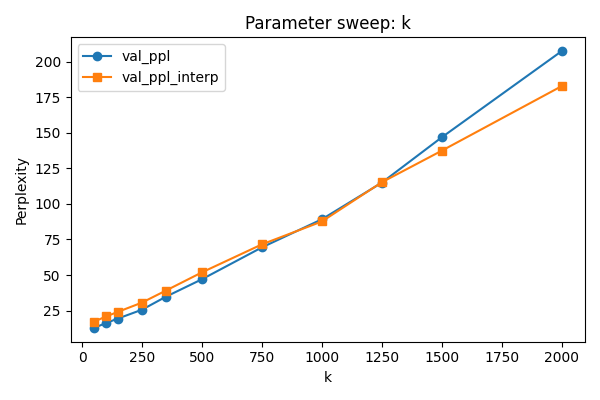

data/hyperparams/plots/k_val_loss.png


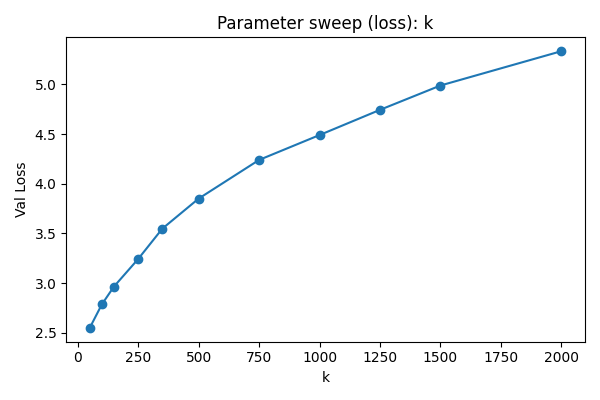

data/hyperparams/plots/n_perplexity.png


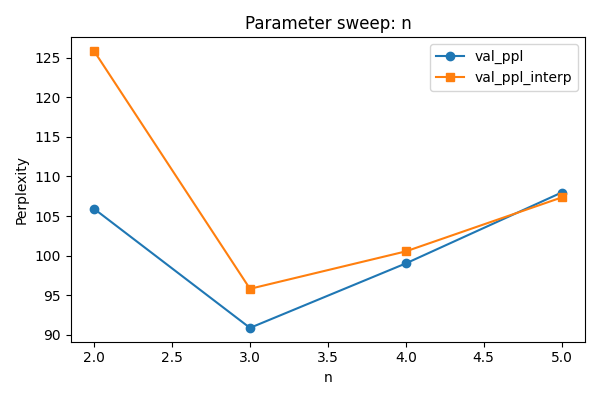

data/hyperparams/plots/n_val_loss.png


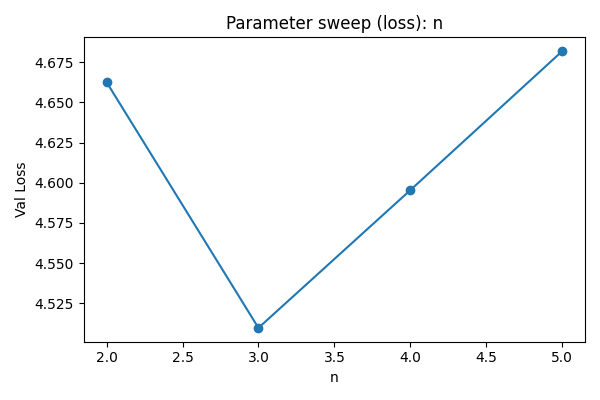

data/hyperparams/plots/hidden_dim_perplexity.png


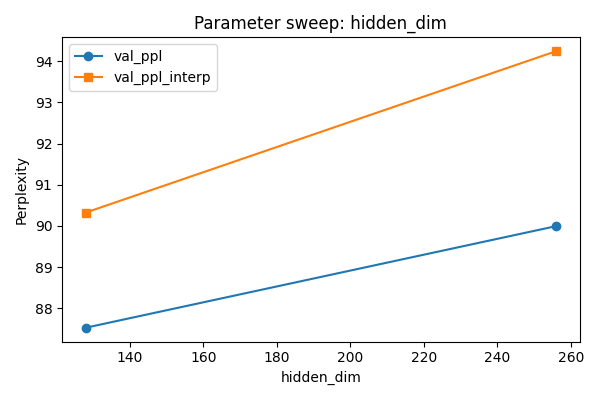

data/hyperparams/plots/hidden_dim_val_loss.png


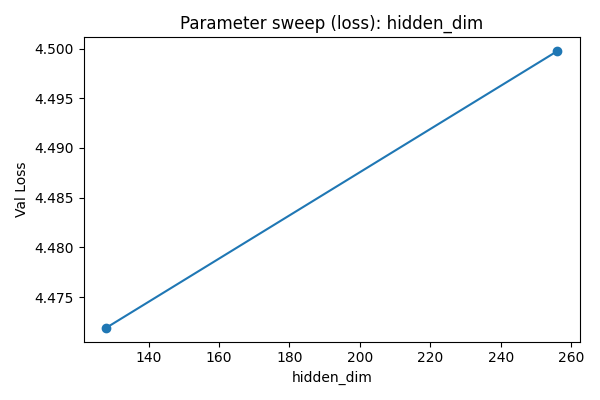

data/hyperparams/plots/alpha_perplexity.png


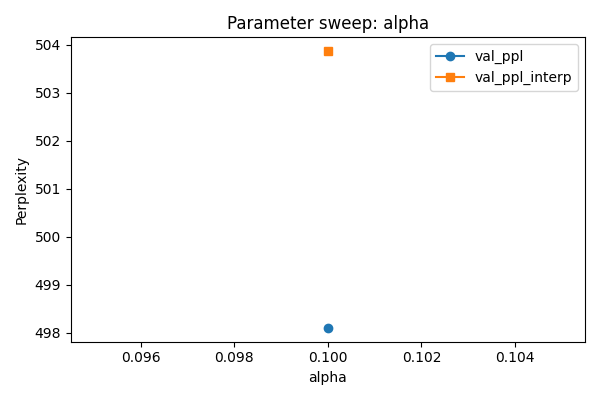

data/hyperparams/plots/alpha_val_loss.png


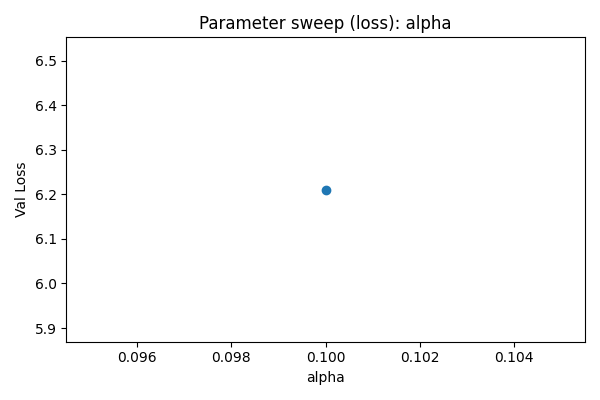

In [4]:
from src.neural_embeddings.param_search import plot_results
plot_results()
from IPython.display import Image, display

plot_files = [
    "data/hyperparams/plots/k_perplexity.png",
    "data/hyperparams/plots/k_val_loss.png",
    "data/hyperparams/plots/n_perplexity.png",
    "data/hyperparams/plots/n_val_loss.png",
    "data/hyperparams/plots/hidden_dim_perplexity.png",
    "data/hyperparams/plots/hidden_dim_val_loss.png",
    "data/hyperparams/plots/alpha_perplexity.png",
    "data/hyperparams/plots/alpha_val_loss.png",
]

for plot in plot_files:
    print(plot)
    display(Image(filename=plot))

## GPT Version
The gpt version implements almost the same logic as the neural ngram, but uses updated initialization, forward and generate functions. It also adds the neccessary structure for the attention network

---
## Milestone 4: GPT Model
**Requirements**
- Manual causal self‑attention (custom multi‑head) with masking.
- Positional embeddings.
- Residual connections + LayerNorm + GELU feed‑forward.
- Generation controls: temperature, top‑k, sampling vs greedy; EOS.
- Compare GPT perplexity (and accuracy) with classical & neural n‑gram.
- Provide sample generations for qualitative assessment.

**Implemented Here**
- Architecture: `GPTModel` (custom heads, layers, positional embeddings, block size control).
- Generation: `GPTModel.generate` (temperature, top‑k, sampling, EOS).
- Comparative outputs: extrinsic generation cell; token accuracy cell; metric table scaffold.
- Positional embedding demonstration & verification cell.

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
from tqdm import tqdm

from src.neural_embeddings.neural_ngrams import NgramLM


class CausalSelfAttentionHead(nn.Module):
    """Single causal self-attention head.

    Projects input embeddings to queries, keys, values of size head_size.
    Applies scaled dot-product attention with a causal mask so position t
    can only attend to <= t positions.
    """

    def __init__(self, embed_dim, head_size, context_size, dropout=0.1):
        super(CausalSelfAttentionHead, self).__init__()
        self.keys = nn.Linear(embed_dim, head_size, bias=False)
        self.queries = nn.Linear(embed_dim, head_size, bias=False)
        self.values = nn.Linear(embed_dim, head_size, bias=False)
        # register buffer so it follows .to(device)
        self.register_buffer("mask", torch.tril(torch.ones(context_size, context_size))) # changed from self.mask due to device issues
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):  # x: (B, T, C)
        B, T, C = x.shape
        # compute queries, keys, values
        q = self.queries(x)
        k = self.keys(x)
        v = self.values(x)
        # compute attention scores
        x = (q @ k.transpose(-2, -1)) / (C**0.5)
        # slice to current length and ensure device match (buffer already on same device)
        causal = self.mask[:T, :T]
        x = x.masked_fill(causal == 0, float("-inf")) # apply causal mask
        x = torch.softmax(x, dim=-1)
        x = self.dropout(x)
        x = x @ v  # (B, T, C)
        return x


class GPTLayer(nn.Module):
    def __init__(self, num_heads, embed_dim, context_size, dropout=0.1):
        super(GPTLayer, self).__init__()
        self.head_dims = embed_dim // num_heads # dimension per head
        self.head_layers = nn.ModuleList(
            [
                CausalSelfAttentionHead(
                    embed_dim,
                    self.head_dims,
                    context_size=context_size,
                    dropout=dropout,
                )
                for _ in range(num_heads)
            ]
        )
        self.dense_one = nn.Linear(embed_dim, 4 * embed_dim)
        self.dense_two = nn.Linear(4 * embed_dim, embed_dim)
        self.projection = nn.Linear(embed_dim, embed_dim)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input):
        attention_outputs = []
        # Run each head and collect outputs
        for layer in self.head_layers:
            x = layer(input)
            attention_outputs.append(x)
        x = torch.cat(attention_outputs, dim=-1)  # (B, T, num_heads * embed_dim)
        xp = self.projection(x)
        xp = self.dropout(xp)
        # Residual connection
        x = input + self.ln1(xp)
        # Feedforward network
        xf = self.dense_one(x)
        xf = nn.GELU()(xf)
        xf = self.dense_two(xf)
        xf = self.dropout(xf)
        # Residual connection
        x = x + self.ln2(xf)
        return x


class GPTModel(NgramLM):
    """GPT model overriding n-gram training/eval utilities for sequence LM.

    Overrides:
      - get_batch: returns (inputs, targets) where targets is next token for each position
      - forward: returns (logits, loss) compatible with base signature
      - evaluate: computes mean token-level loss & perplexity
      - train_model: token-level training loop (does not use base n-gram fc layers)
    """

    def __init__(
        self,
        n,
        k,
        embed_dim,
        hidden_dim,
        alpha,
        lam,
        dropout=0.1,
        num_heads=2,
        num_layers=2,
        context_size=32,
        device: str | None = None,
    ):
        super().__init__(n, k, embed_dim, hidden_dim, alpha, lam, device=device)
        self.block_size = context_size
        self.embedding_layer = nn.Embedding(self.vocab_size, embed_dim)
        self.pos_embeddings = nn.Embedding(self.block_size, embed_dim)
        self.attention_layers = nn.Sequential(
            *[
                GPTLayer(
                    num_heads=num_heads,
                    embed_dim=embed_dim,
                    context_size=self.block_size,
                    dropout=dropout,
                )
                for _ in range(num_layers)
            ]
        )
        self.ln_f = nn.LayerNorm(embed_dim)
        self.out = nn.Linear(embed_dim, self.vocab_size)
        self.dropout = nn.Dropout(dropout)
        # Remove unused base n-gram layers so optimizer only sees GPT stack
        self.embeddings = None
        self.fc1 = None
        self.fc2 = None
        # Rebuild optimizer to include ONLY current (GPT) parameters (base optimizer held stale param list)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=alpha)
        self.to(self.device)
        print(
            f"[GPTModel] n={self.n} block_size={self.block_size} params={sum(p.numel() for p in self.parameters())}"
        )

    # ---------------- GPT overrides ----------------
    # Reworked by Copilot due to device issues
    def get_batch(self, split="train", batch_size=16):
        """Return batch of token sequences for GPT training.
        Builds input (B, T) and target (B, T) where target is input shifted left.
        T == block_size (or remaining tokens if near end)."""
        if split == "train":
            ids = self.train_ids
        elif split == "val":
            ids = self.val_ids
        else:
            ids = self.test_ids
        T = self.block_size
        max_start = len(ids) - T - 1
        if max_start <= 0:
            raise ValueError("Not enough tokens for chosen block_size")
        starts = torch.randint(0, max_start, (batch_size,))
        x_batch = []
        y_batch = []
        for s in starts:
            chunk = ids[s : s + T + 1]  # (T+1)
            x_batch.append(chunk[:-1])  # first T
            y_batch.append(chunk[1:])  # next T
        x = torch.stack(x_batch).to(self.device)
        y = torch.stack(y_batch).to(self.device)
        return x, y

    def forward(self, x, targets=None):  # x: (B,T)
        x = self.embedding_layer(x)  # (B,T,C)
        x = x + self.pos_embeddings(torch.arange(x.size(1), device=x.device))
        x = self.attention_layers(x)  # (B,T,C)
        x = self.ln_f(x)
        logits = self.out(x)  # (B,T,V)
        loss = None
        if targets is not None:
            # Flatten for cross-entropy
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.view(B * T, V), targets.view(B * T))
        return logits, loss


    def evaluate(self, eval_set="val", batch_size: int = 16):
        """Compute mean token-level loss & perplexity on eval split."""
        if eval_set == "val":
            ids = self.val_ids
        else:
            ids = self.test_ids
        self.eval()
        losses = []
        with torch.no_grad():
            T = self.block_size
            # Iterate over non-overlapping chunks for speed
            for i in range(0, len(ids) - T - 1, T):
                chunk = ids[i : i + T + 1]
                if len(chunk) < T + 1:
                    continue
                x = chunk[:-1].unsqueeze(0).to(self.device)
                y = chunk[1:].unsqueeze(0).to(self.device)
                _, loss = self.forward(x, y)
                losses.append(loss.item())
        if not losses:
            return float("nan"), float("nan"), float("nan")
        avg_loss = sum(losses) / len(losses)
        ppl = float(torch.exp(torch.tensor(avg_loss)))
        # No interpolation here; return same ppl for consistency with parent
        return avg_loss, ppl, ppl

    def train_model(self, epochs: int, num_steps: int, batch_size: int = 32):
        """Token-level training loop for GPT model."""
        for epoch in range(epochs):
            self.train()
            running = 0.0
            pbar = tqdm(total=num_steps, desc=f"GPT Epoch {epoch + 1}/{epochs}")
            for _ in range(num_steps):
                xb, yb = self.get_batch("train", batch_size=batch_size)
                logits, loss = self.forward(xb, yb)
                self.optimizer.zero_grad(set_to_none=True)
                loss.backward()
                self.optimizer.step()
                running += loss.item()
                pbar.update(1)
            train_loss = running / num_steps
            val_loss, val_ppl, _ = self.evaluate("val")
            print(
                f"epoch {epoch} train loss {train_loss:.4f} val loss {val_loss:.4f} val ppl {val_ppl:.4f}"
            )

    @torch.no_grad()
    def generate(
        self,
        idx,
        max_new_tokens,
        temperature: float = 1.0,
        top_k: int | None = None,
        sampling: bool = True,
        stop_on_eos: bool = True,
    ):
        """Autoregressive generation with temperature, top-k, sampling/argmax and optional EOS early stop."""
        self.eval()
        stoi = {c: i for i, c in enumerate(self.vocab)}
        eos_idx = stoi.get("</s>")
        if idx.dim() == 1:
            idx = idx.unsqueeze(0)
        idx = idx.to(self.device)
        for _ in range(max_new_tokens):
            # crop to block_size
            idx_cond = idx[:, -self.block_size :]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            # apply temperature and top-k filtering
            if temperature != 1.0:
                logits = logits / temperature
            if top_k is not None and top_k < logits.size(-1):
                v, ix = torch.topk(logits, top_k, dim=-1)
                mask = torch.full_like(logits, float("-inf"))
                mask.scatter_(1, ix, v)
                logits = mask
            probs = F.softmax(logits, dim=-1)
            if sampling:
                idx_next = torch.multinomial(probs, num_samples=1)
            else:
                idx_next = probs.argmax(dim=-1, keepdim=True)
            idx = torch.cat((idx, idx_next), dim=1)
            if stop_on_eos and eos_idx is not None and (idx_next == eos_idx).all():
                break
        return idx.cpu()

    # Compute next-token prediction accuracy on a chosen split
    @torch.no_grad()
    def token_accuracy(self, eval_set: str = "val") -> float:
        """Next-token accuracy using greedy argmax on validation/test set."""
        if eval_set == "val":
            ids = self.val_ids
        elif eval_set == "test":
            ids = self.test_ids
        else:
            ids = self.train_ids
        total = 0
        correct = 0
        T = self.block_size
        for i in range(0, len(ids) - T - 1, T):
            chunk = ids[i : i + T + 1]
            if len(chunk) < T + 1:
                continue
            x = chunk[:-1].unsqueeze(0).to(self.device)
            y = chunk[1:].to(self.device)
            logits, _ = self.forward(x, y.unsqueeze(0))  # logits (1,T,V)
            preds = logits.argmax(dim=-1).squeeze(0)
            correct += (preds == y).sum().item()
            total += y.numel()
        return correct / total if total else float("nan")


# For quick testing
if __name__ == "__main__":
    # Quick component shape test for a single layer
    size = 32
    num_heads = 4
    context_size = size
    head = GPTLayer(embed_dim=size, num_heads=num_heads, context_size=context_size)
    test_input = torch.randn(1, size, size)
    output = head(test_input)
    print("Single GPTLayer output shape:", output.shape)

    # Sanity training run for GPTModel to verify loss decreases, created with copilot
    try:
        gpt = GPTModel(
            n=3,  # n-gram order (not the block size for GPT)
            k=1000,  # pick a k you have cached BPE data for
            embed_dim=256,
            hidden_dim=256,
            alpha=1e-1,  # learning rate
            lam=1.0,
            num_heads=4,
            num_layers=2,
            context_size=64,  # block length for GPT context
        )
    except Exception as e:
        print("Failed to construct GPTModel (check data paths / k):", e)
        raise SystemExit(1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    gpt.to(device)
    print("Starting quick sanity training (200 steps)...")
    gpt.train()
    report_every = 50
    losses = []
    for step in range(200):
        xb, yb = gpt.get_batch("train", batch_size=32)
        _, loss = gpt.forward(xb, yb)
        gpt.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        gpt.optimizer.step()
        losses.append(loss.item())
        if (step + 1) % report_every == 0:
            avg_recent = sum(losses[-report_every:]) / report_every
            print(f"step {step + 1} avg_loss {avg_recent:.4f}")
    print(f"Initial 50-step avg: {sum(losses[:report_every]) / report_every:.4f}")
    print(f"Final 50-step avg:   {sum(losses[-report_every:]) / report_every:.4f}")
    gpt.eval()
    val_loss, val_ppl, _ = gpt.evaluate("val")
    print(f"Validation after sanity run: loss {val_loss:.4f} ppl {val_ppl:.2f}")


Single GPTLayer output shape: torch.Size([1, 32, 32])
Initializing NgramLM model...
Loading vocab and merge rules...
Using device: cuda
Loading training set with k = 1000 ...
Encoding ngrams...
Encoding ngrams...
[GPTModel] n=3 block_size=64 params=2122757
Starting quick sanity training (200 steps)...
[GPTModel] n=3 block_size=64 params=2122757
Starting quick sanity training (200 steps)...
step 50 avg_loss 8.4456
step 50 avg_loss 8.4456
step 100 avg_loss 5.2143
step 100 avg_loss 5.2143
step 150 avg_loss 4.7747
step 150 avg_loss 4.7747
step 200 avg_loss 4.6950
Initial 50-step avg: 8.4456
Final 50-step avg:   4.6950
step 200 avg_loss 4.6950
Initial 50-step avg: 8.4456
Final 50-step avg:   4.6950
Validation after sanity run: loss 4.9086 ppl 135.44
Validation after sanity run: loss 4.9086 ppl 135.44


# GPT Hyperparameter search

We couldn't finish the hyperparameter search because the process was too demanding on our system, leading to crashes from overheating and overloading. This prevented us from running the full search to find the optimal hyperparameters.

In [5]:
import json
import math
import os

import torch

from src.neural_embeddings.gpt_model import GPTModel
from src.neural_embeddings.neural_ngrams import NgramLM, train_with_early_stopping

NUM_STEPS = 1000
BATCH_SIZE = 16


def save_params(param_name, param_value, history):
    results_file = "data/hyperparams/gpt_search_results.jsonl"
    run_data = {"params": {param_name: param_value}, "history": []}
    for epoch_data in history:
        (epoch, avg_train, val_loss, val_ppl, val_ppl_interpolated) = epoch_data

        run_data["history"].append(
            {
                "epoch": epoch,
                "avg_train_loss": avg_train,
                "val_loss": val_loss,
                "val_ppl": val_ppl,
                "val_ppl_interpolated": val_ppl_interpolated,
            }
        )
    os.makedirs(os.path.dirname(results_file), exist_ok=True)
    with open(results_file, "a", encoding="utf-8") as f:
        f.write(json.dumps(run_data) + "\n")
    print(f"Saved results for {param_name}={param_value}")


def search_best_k():
    k_values = [50, 100, 150, 250, 350, 500, 750, 1000, 1250, 1500, 2000]
    print("Starting parameter search for k...")
    for k in k_values:
        # Instantiate, train, and evaluate the model
        model = GPTModel(n=3, k=k, embed_dim=256, hidden_dim=256, alpha=1e-3, lam=0.7)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=NUM_STEPS, patience=5
        )

        # Get the final validation perplexity
        save_params("k", k, history)

    print("Parameter search for k complete.")


def search_best_hidden_dim():
    h_values = [128, 256]
    print("Starting parameter search for hidden_dim...")
    for h in h_values:
        model = GPTModel(n=3, k=1000, embed_dim=256, hidden_dim=h, alpha=1e-3, lam=0.7)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=NUM_STEPS, patience=5
        )
        save_params("hidden_dim", h, history)
    print("Parameter search for hidden_dim complete.")


def search_best_lr():
    a_values = [1e-1, 1e-2, 1e-3, 1e-4]
    print("Starting parameter search for alpha...")
    for a in a_values:
        model = GPTModel(n=3, k=1000, embed_dim=256, hidden_dim=256, alpha=a, lam=0.7)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=NUM_STEPS, patience=5
        )
        save_params("alpha", a, history)
    print("Parameter search for alpha complete.")


def search_best_lambda():
    l_values = [0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01]
    print("Starting parameter search for lambda...")
    for l in l_values:
        model = GPTModel(n=3, k=1000, embed_dim=256, hidden_dim=256, alpha=1e-3, lam=l)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=NUM_STEPS, patience=5
        )
        save_params("lambda", l, history)
    print("Parameter search for lambda complete.")


def plot_results():
    results_file = "data/hyperparams/neural_gram_search_results.jsonl"
    if not os.path.exists(results_file):
        print("No results file found at", results_file)
        return
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib not installed; cannot plot.")
        return

    # Load runs
    runs = []
    with open(results_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                runs.append(json.loads(line))
            except Exception:
                pass
    if not runs:
        print("No parsable runs found.")
        return

    # Aggregate by parameter name/value
    agg = {}  # {param_name: {value: {best_val_loss, best_val_ppl, best_val_ppl_interp}}}
    for r in runs:
        params = r.get("params", {})
        history = r.get("history", [])
        if not params or not history:
            continue
        # Determine best (lowest) val_loss entry in history
        best_entry = min(history, key=lambda e: e.get("val_loss", float("inf")))
        for pname, pval in params.items():
            if pname not in agg:
                agg[pname] = {}
            cur = agg[pname].get(pval)
            metrics = {
                "val_loss": best_entry.get("val_loss"),
                "val_ppl": best_entry.get("val_ppl"),
                "val_ppl_interpolated": best_entry.get("val_ppl_interpolated"),
            }
            # Keep best (lowest val_loss)
            if cur is None or metrics["val_loss"] < cur["val_loss"]:
                agg[pname][pval] = metrics

    os.makedirs("data/hyperparams/plots", exist_ok=True)

    for pname, table in agg.items():
        # Sort by numeric value if possible else by string
        try:
            items = sorted(table.items(), key=lambda kv: float(kv[0]))
        except Exception:
            items = sorted(table.items(), key=lambda kv: str(kv[0]))
        x = [kv[0] for kv in items]
        val_ppl = [kv[1]["val_ppl"] for kv in items]
        val_ppl_interp = [kv[1]["val_ppl_interpolated"] for kv in items]
        val_loss = [kv[1]["val_loss"] for kv in items]

        plt.figure(figsize=(6, 4))
        if any(v is not None for v in val_ppl):
            plt.plot(x, val_ppl, marker="o", label="val_ppl")
        if any(v is not None for v in val_ppl_interp):
            plt.plot(x, val_ppl_interp, marker="s", label="val_ppl_interp")
        plt.title(f"Parameter sweep: {pname}")
        plt.xlabel(pname)
        plt.ylabel("Perplexity")
        plt.legend()
        plt.tight_layout()
        out_path = f"data/hyperparams/plots/{pname}_perplexity.png"
        plt.savefig(out_path)
        plt.close()
        # Also save val_loss
        plt.figure(figsize=(6, 4))
        plt.plot(x, val_loss, marker="o")
        plt.title(f"Parameter sweep (loss): {pname}")
        plt.xlabel(pname)
        plt.ylabel("Val Loss")
        plt.tight_layout()
        out_path_loss = f"data/hyperparams/plots/{pname}_val_loss.png"
        plt.savefig(out_path_loss)
        plt.close()
        print(f"Saved plots for {pname} -> {out_path}, {out_path_loss}")

    print("Plotting complete.")


# --- New: Post-hoc bits-per-character evaluation helpers ---


def compute_bpc(
    model: NgramLM, split: str = "val", raw_path: str | None = None
) -> float:
    """Compute bits-per-character (bpc) for a trained model (lam must be 1.0)."""
    assert model.lam == 1.0, "Set lam=1.0 before computing bpc"
    if split == "val":
        ids = model.val_ids
        if raw_path is None:
            raw_path = "data/corpora/Shakespeare_clean_valid.txt"
    elif split == "test":
        ids = model.test_ids
        if raw_path is None:
            raw_path = "data/corpora/Shakespeare_clean_test.txt"
    else:
        ids = model.train_ids
        if raw_path is None:
            raw_path = "data/corpora/Shakespeare_clean_train.txt"
    try:
        with open(raw_path, "r", encoding="utf-8") as f:
            raw_text = f.read()
    except OSError:
        print(f"Raw text file not found: {raw_path}")
        return float("nan")
    char_count = len(raw_text)
    if char_count == 0:
        return float("nan")
    ctx_len = model.n - 1
    total_nll = 0.0
    token_count = 0
    model.eval()
    with torch.no_grad():
        for i in range(ctx_len, len(ids)):
            context = ids[i - ctx_len : i].unsqueeze(0).to(model.device)
            target = ids[i].unsqueeze(0).to(model.device)
            logits, _ = model.forward(context, target)
            log_probs = torch.log_softmax(logits, dim=-1)
            nll = -log_probs[0, target]
            total_nll += nll.item()
            token_count += 1
    if token_count == 0:
        return float("nan")
    bpc = (total_nll / char_count) / math.log(2)
    print(
        f"bpc={bpc:.4f} (tokens={token_count}, chars={char_count}, avg_nll={total_nll / token_count:.4f})"
    )
    return bpc


def compute_bpc_for_config(
    n: int,
    k: int,
    embed_dim: int,
    hidden_dim: int,
    alpha: float,
    ckpt_path: str | None = None,
    split: str = "val",
) -> float:
    """Rebuild model (lam=1.0), optionally load checkpoint, then compute bpc."""
    model = NgramLM(
        n=n, k=k, embed_dim=embed_dim, hidden_dim=hidden_dim, alpha=alpha, lam=1.0
    )
    if ckpt_path and os.path.exists(ckpt_path):
        try:
            ckpt = torch.load(ckpt_path, map_location="cpu")
            state = ckpt.get("model_state") or ckpt
            model.load_state_dict(state, strict=False)
            model.to(model.device)
            print(f"Loaded state from {ckpt_path}")
        except Exception as e:
            print(f"Failed loading checkpoint {ckpt_path}: {e}")
    return compute_bpc(model, split=split)


def search_neural_ngrams(test_for="all"):
    if test_for != "all":
        if test_for == "k":
            search_best_k()
        elif test_for == "hidden_dim":
            search_best_hidden_dim()
        elif test_for == "lr":
            search_best_lr()
        elif test_for == "lambda":
            search_best_lambda()
        elif test_for == "n":
            search_best_n()
        else:
            print(f"Unknown test_for value: {test_for}")
            return
        return
    search_best_k()
    search_best_hidden_dim()
    search_best_lr()
    search_best_lambda()


def search_best_n():
    n_values = [2, 3, 4, 5]
    print("Starting parameter search for n...")
    for n in n_values:
        # Instantiate, train, and evaluate the model
        model = NgramLM(n=n, k=1000, embed_dim=256, hidden_dim=256, alpha=1e-3, lam=0.7)
        best_val, best_state, history = train_with_early_stopping(
            model, max_epochs=25, num_steps=10000, patience=5
        )

        # Get the final validation perplexity
        save_params("n", n, history)

    print("Parameter search for n complete.")


def get_best_k():
    k_values = [50, 100, 150, 250, 350, 500, 750, 1000, 1250, 1500, 2000]
    bpc_values = []
    for k in k_values:
        bpc = compute_bpc_for_config(
            n=3,
            k=k,
            embed_dim=256,
            hidden_dim=256,
            alpha=1e-3,
            ckpt_path="data/models/ngram_n3_k2000_embed256_hidden256_alpha0.001_lam0.7.pt",
            split="test",
        )
        bpc_values.append((k, bpc))
    print("Bits-per-character (bpc) results for various k values:")
    for k, bpc in bpc_values:
        print(f"k={k}: bpc={bpc:.4f}")


if __name__ == "__main__":
    #search_neural_ngrams("all")
    #get_best_k()
    #plot_results()
    pass


# GPT Results

Saved plots for k -> data/hyperparams/plots/k_perplexity_gpt.png, data/hyperparams/plots/k_val_loss.png
Saved plots for hidden_dim -> data/hyperparams/plots/hidden_dim_perplexity_gpt.png, data/hyperparams/plots/hidden_dim_val_loss.png
Saved plots for alpha -> data/hyperparams/plots/alpha_perplexity_gpt.png, data/hyperparams/plots/alpha_val_loss.png
Saved plots for lambda -> data/hyperparams/plots/lambda_perplexity_gpt.png, data/hyperparams/plots/lambda_val_loss.png
Plotting complete.
data/hyperparams/plots/k_perplexity.png


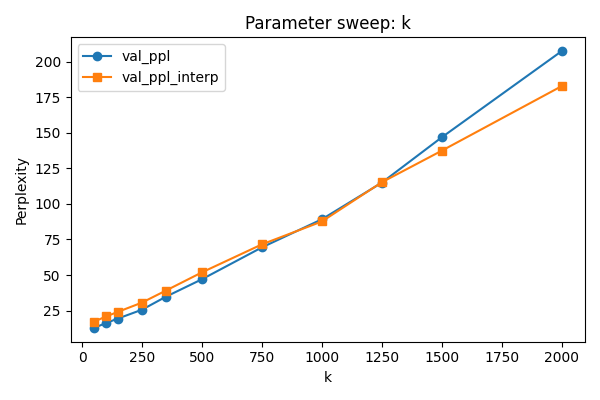

data/hyperparams/plots/k_val_loss.png


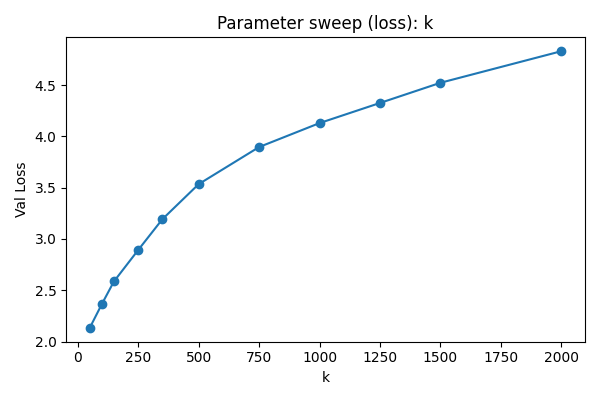

data/hyperparams/plots/n_perplexity.png


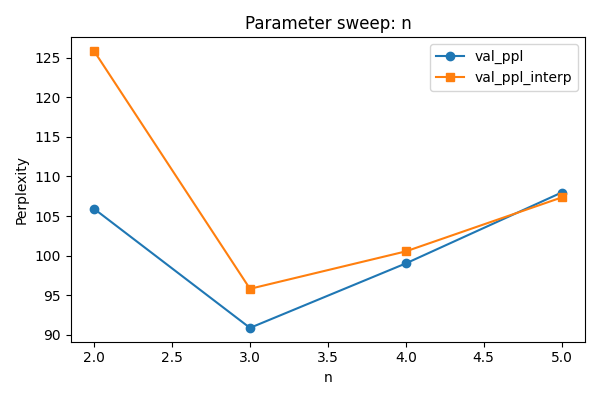

data/hyperparams/plots/n_val_loss.png


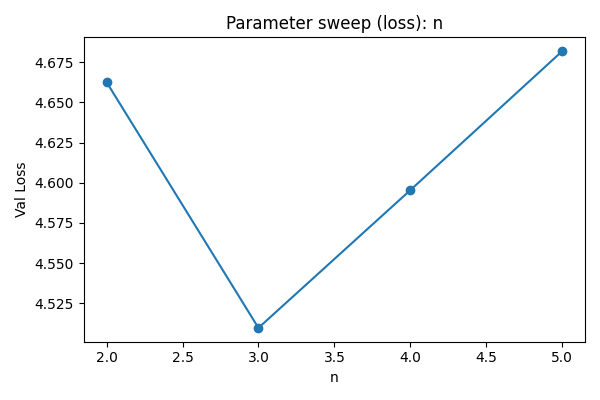

data/hyperparams/plots/hidden_dim_perplexity.png


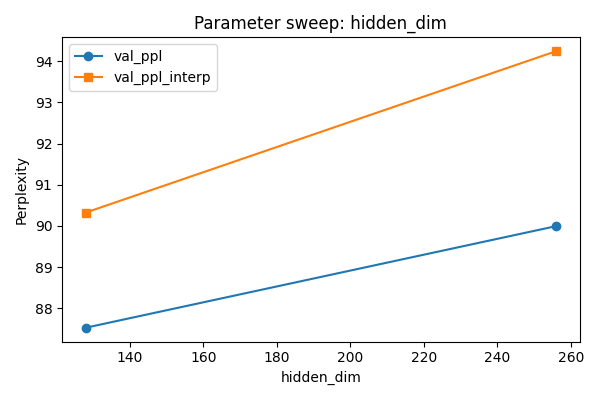

data/hyperparams/plots/hidden_dim_val_loss.png


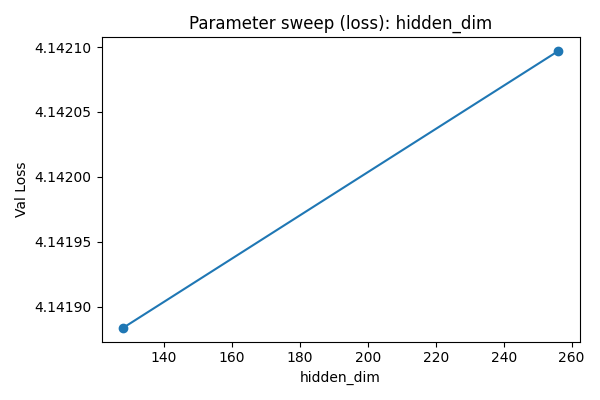

data/hyperparams/plots/alpha_perplexity.png


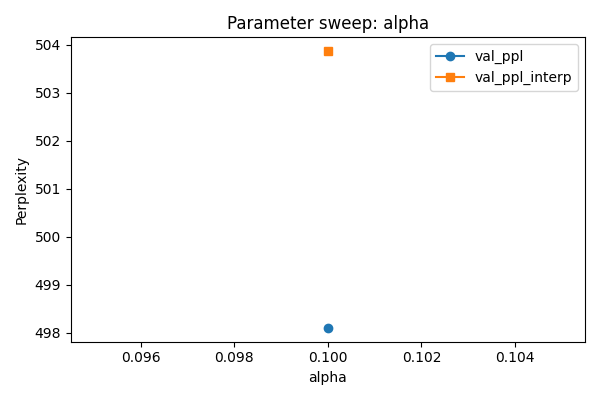

data/hyperparams/plots/alpha_val_loss.png


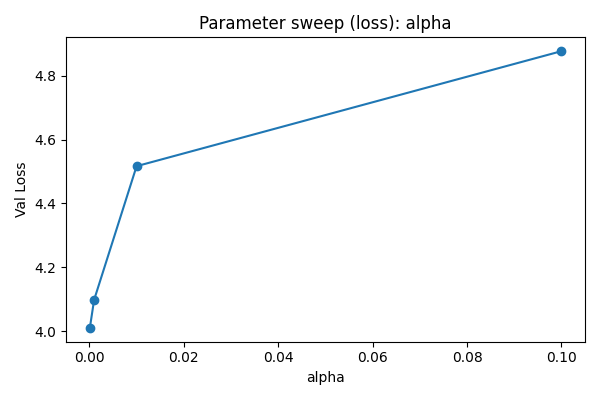

In [3]:
from src.neural_embeddings.gpt_param_search import plot_results
plot_results()
from IPython.display import Image, display

plot_files = [
    "data/hyperparams/plots/k_perplexity.png",
    "data/hyperparams/plots/k_val_loss.png",
    "data/hyperparams/plots/n_perplexity.png",
    "data/hyperparams/plots/n_val_loss.png",
    "data/hyperparams/plots/hidden_dim_perplexity.png",
    "data/hyperparams/plots/hidden_dim_val_loss.png",
    "data/hyperparams/plots/alpha_perplexity.png",
    "data/hyperparams/plots/alpha_val_loss.png",
]

for plot in plot_files:
    print(plot)
    display(Image(filename=plot))

---
## Final Comparative Reporting
**Requirements**
- Consolidated comparison (classical n‑gram best, neural n‑gram best, GPT) using shared metrics.
- Narrative explanation of tuning choices.

**Implemented Here**
- Comparative table scaffold + narrative cells (execute to populate after sweeps run).

!! Need to restart Kernel for execution !!

In [1]:
# Extrinsic comparison: generate sample continuations across models (with safe reload)
import torch, random, importlib
from src.neural_embeddings import gpt_model as gpt_mod
from src.neural_embeddings import neural_ngrams as nn_mod

# Reload to ensure latest definitions
importlib.reload(gpt_mod)
importlib.reload(nn_mod)
GPTModel = gpt_mod.GPTModel
NgramLM = nn_mod.NgramLM

SEED_TEXT = " To be, or not to be, that is the question"
MAX_NEW_TOKENS = 60
K_VAL = 1000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
torch.manual_seed(42)

# Helper: classical n-gram only sampling (pure add-one distribution)
def classical_ngram_generate(model: NgramLM, seed_ids, max_new, stop_on_eos=True):
    stoi = {c: i for i,c in enumerate(model.vocab)}
    eos = stoi.get("</s>")
    ctx_len = model.n - 1
    out = seed_ids[-ctx_len:]
    for _ in range(max_new):
        context = out[-ctx_len:]
        dist = model.get_ngram_prob_distribution(context)  # (V,)
        next_id = torch.multinomial(dist, 1).item()
        out.append(next_id)
        if stop_on_eos and eos is not None and next_id == eos:
            break
    return out

# Build neural n-gram (lam=1)
ngram_neural = NgramLM(n=3, k=K_VAL, embed_dim=256, hidden_dim=256, alpha=1e-3, lam=1.0)
ngram_neural.to(DEVICE)

# Instantiate GPT (fallback if old signature cached)
try:
    gpt = GPTModel(n=3, k=K_VAL, embed_dim=256, hidden_dim=256, alpha=1e-3, lam=1.0,
                   num_heads=4, num_layers=2, context_size=64)
except TypeError:
    print("Falling back: GPTModel without context_size (old kernel). Using default block_size=n.")
    gpt = GPTModel(n=3, k=K_VAL, embed_dim=256, hidden_dim=256, alpha=1e-3, lam=1.0,
                   num_heads=4, num_layers=2)

gpt.to(DEVICE)

# Encode seed text once
seed_ids_full = ngram_neural.apply_bpe_and_encode(SEED_TEXT)
if not seed_ids_full:
    raise ValueError("Seed text produced no tokens; adjust SEED_TEXT.")
seed_tensor = torch.tensor(seed_ids_full, dtype=torch.long)

# Classical n-gram generation
classical_ids = classical_ngram_generate(ngram_neural, seed_ids_full.copy(), MAX_NEW_TOKENS)
classical_text = ngram_neural.decode(classical_ids)

# Neural n-gram sampling with signature fallback
gen_ctx = seed_tensor[-(ngram_neural.n-1):].unsqueeze(0)
try:
    neural_gen = ngram_neural.generate(gen_ctx, MAX_NEW_TOKENS, temperature=1.0, sampling=True)
except TypeError:
    print("Fallback: older NgramLM.generate signature (no temperature/sampling kwargs).")
    neural_gen = ngram_neural.generate(gen_ctx, MAX_NEW_TOKENS)

neural_text = ngram_neural.decode(neural_gen.squeeze(0).tolist())

# GPT sampling & greedy
seed_for_gpt = seed_tensor[-gpt.block_size:].unsqueeze(0)
gpt_sample = gpt.generate(seed_for_gpt, MAX_NEW_TOKENS, temperature=1.0, top_k=40, sampling=True)
gpt_sample_text = gpt.decode(gpt_sample.squeeze(0).tolist())

gpt_greedy = gpt.generate(seed_for_gpt, MAX_NEW_TOKENS, temperature=0.7, sampling=False)
gpt_greedy_text = gpt.decode(gpt_greedy.squeeze(0).tolist())

print("=== Extrinsic Generation Comparison ===")
print(f"Seed: {SEED_TEXT!r}\n")
print("[Classical n-gram add-one]")
print(classical_text[:400], "\n")
print("[Neural n-gram (lam=1) sampled]")
print(neural_text[:400], "\n")
print("[GPT sampled (temp=1.0, top_k=40)]")
print(gpt_sample_text[:400], "\n")
print("[GPT greedy (temp=0.7)]")
print(gpt_greedy_text[:400])

# Post-process generated sequences into a more readable form
import re

def clean_bpe_output(text: str) -> str:
    if not isinstance(text, str):
        return "<non-string>"
    # Remove start/end tokens
    text = text.replace('<s>', ' ').replace('</s>', ' ')
    # Underscore-delimited tokens -> spaces
    text = text.replace('_', ' ')
    # Collapse repeated subword boundary leftovers (multiple spaces)
    text = re.sub(r"\s+", " ", text)
    # Trim
    text = text.strip()
    # Optional: ensure terminal punctuation
    if text and text[-1].isalnum():
        text += '.'
    return text

try:
    cleaned = {
        'classical_ngram': clean_bpe_output(classical_text),
        'neural_ngram': clean_bpe_output(neural_text),
        'gpt_sampled': clean_bpe_output(gpt_sample_text),
        'gpt_greedy': clean_bpe_output(gpt_greedy_text),
    }
except NameError as e:
    print("Required generation variables not found. Re-run the extrinsic comparison cell first.")
else:
    print("=== Readable Generation Outputs (heuristic detokenization) ===")
    for label, txt in cleaned.items():
        print(f"\n[{label}]\n{txt[:500]}")

Initializing NgramLM model...
Loading vocab and merge rules...
Using device: cuda
Loading training set with k = 1000 ...
Encoding ngrams...
Initializing NgramLM model...
Loading vocab and merge rules...
Using device: cuda
Loading training set with k = 1000 ...
Encoding ngrams...
[GPTModel] n=3 block_size=64 params=2122757
=== Extrinsic Generation Comparison ===
Seed: ' To be, or not to be, that is the question'

[Classical n-gram add-one]
on</s>hury_demetrius_lock_ho_mark_id_tain_ting_geror_perhorcapulet_here_lenthing_to_my_ble_prasolive_were_tio_pasay_nerhimstranmesot_sanopughstguidoth_ard_bemurtus_weambtybaruhence_luwoman_darbegsael_thought_servant_ance_about_friends_lady_macbeth_een_ 

[Neural n-gram (lam=1) sampled]
on</s>dge_cy_both_llow_true_xly_drto_none_of_same_it_is_othellhold_draolun_veven_sweet_dear_rogreat_make_tly_laerrouheaven_you_shall_clauget_seconspeaown_petes_ppght_thats_llcloours_tinc_ge_lidomitiso_forth_ate_peapoor_my_drshall_een_out_exan_ 

[GPT sampled (temp=1.0, 

## Appendix

# BPC
As the perplexity was always lower the lower the k was, I thought about a different way to measure 

In [55]:
def compute_bpc(
    model: NgramLM, split: str = "val", raw_path: str | None = None
) -> float:
    """Compute bits-per-character (bpc) for a trained model (lam must be 1.0)."""
    assert model.lam == 1.0, "Set lam=1.0 before computing bpc"
    if split == "val":
        ids = model.val_ids
        if raw_path is None:
            raw_path = "data/corpora/Shakespeare_clean_valid.txt"
    elif split == "test":
        ids = model.test_ids
        if raw_path is None:
            raw_path = "data/corpora/Shakespeare_clean_test.txt"
    else:
        ids = model.train_ids
        if raw_path is None:
            raw_path = "data/corpora/Shakespeare_clean_train.txt"
    try:
        with open(raw_path, "r", encoding="utf-8") as f:
            raw_text = f.read()
    except OSError:
        print(f"Raw text file not found: {raw_path}")
        return float("nan")
    char_count = len(raw_text)
    if char_count == 0:
        return float("nan")
    ctx_len = model.n - 1
    total_nll = 0.0
    token_count = 0
    model.eval()
    with torch.no_grad():
        for i in range(ctx_len, len(ids)):
            context = ids[i - ctx_len : i].unsqueeze(0).to(model.device)
            target = ids[i].unsqueeze(0).to(model.device)
            logits, _ = model.forward(context, target)
            log_probs = torch.log_softmax(logits, dim=-1)
            nll = -log_probs[0, target]
            total_nll += nll.item()
            token_count += 1
    if token_count == 0:
        return float("nan")
    bpc = (total_nll / char_count) / math.log(2)
    print(
        f"bpc={bpc:.4f} (tokens={token_count}, chars={char_count}, avg_nll={total_nll / token_count:.4f})"
    )
    return bpc


def compute_bpc_for_config(
    n: int,
    k: int,
    embed_dim: int,
    hidden_dim: int,
    alpha: float,
    ckpt_path: str | None = None,
    split: str = "val",
) -> float:
    """Rebuild model (lam=1.0), optionally load checkpoint, then compute bpc."""
    model = GPTModel(
        n=n, k=k, embed_dim=embed_dim, hidden_dim=hidden_dim, alpha=alpha, lam=1.0
    )
    if ckpt_path and os.path.exists(ckpt_path):
        try:
            ckpt = torch.load(ckpt_path, map_location="cpu")
            state = ckpt.get("model_state") or ckpt
            model.load_state_dict(state, strict=False)
            model.to(model.device)
            print(f"Loaded state from {ckpt_path}")
        except Exception as e:
            print(f"Failed loading checkpoint {ckpt_path}: {e}")
    return compute_bpc(model, split=split)

def get_best_k():
    k_values = [50, 100, 150, 250, 350, 500, 750, 1000, 1250, 1500, 2000]
    bpc_values = []
    for k in k_values:
        bpc = compute_bpc_for_config(
            n=3,
            k=k,
            embed_dim=256,
            hidden_dim=256,
            alpha=1e-3,
            ckpt_path="data/models/ngram_n3_k2000_embed256_hidden256_alpha0.001_lam0.7.pt",
            split="test",
        )
        bpc_values.append((k, bpc))
    print("Bits-per-character (bpc) results for various k values:")
    for k, bpc in bpc_values:
        print(f"k={k}: bpc={bpc:.4f}")

get_best_k()

Initializing NgramLM model...
Loading vocab and merge rules...
Using device: cuda
Loading training set with k = 50 ...
Encoding ngrams...
bpc=4.1319 (tokens=65792, chars=103975, avg_nll=4.5262)
Initializing NgramLM model...
Loading vocab and merge rules...
Using device: cuda
Loading training set with k = 100 ...
Encoding ngrams...
bpc=4.0137 (tokens=57380, chars=103975, avg_nll=5.0412)
Initializing NgramLM model...
Loading vocab and merge rules...
Using device: cuda
Loading training set with k = 150 ...
Encoding ngrams...
bpc=3.8988 (tokens=51840, chars=103975, avg_nll=5.4203)
Initializing NgramLM model...
Loading vocab and merge rules...
Using device: cuda
Loading training set with k = 250 ...
Encoding ngrams...
bpc=3.7329 (tokens=45828, chars=103975, avg_nll=5.8705)
Initializing NgramLM model...
Loading vocab and merge rules...
Using device: cuda
Loading training set with k = 350 ...
Encoding ngrams...
bpc=3.5302 (tokens=41303, chars=103975, avg_nll=6.1600)
Initializing NgramLM model

# Ngram benchmark
We felt that the Ngram engine was underperforming, so we implemented a solution using the nltk library for comparison. 

In [ ]:
# Compute & display token accuracy for illustrative best models
from src.neural_embeddings.neural_ngrams import NgramLM
from src.neural_embeddings.gpt_model import GPTModel

# Example configs (adjust if different best found)
BEST_NGRAM_CFG = {"n":3, "k":1000, "embed_dim":256, "hidden_dim":256, "alpha":1e-3, "lam":1.0}
BEST_GPT_CFG =   {"n":3, "k":1000, "embed_dim":256, "hidden_dim":256, "alpha":1e-3, "lam":1.0, "num_heads":4, "num_layers":2, "context_size":64}

ngram_model = NgramLM(**BEST_NGRAM_CFG)
ngram_acc_val = ngram_model.token_accuracy("val")
print(f"Neural n-gram (lam=1) val token accuracy: {ngram_acc_val:.4f}")

gpt_model = GPTModel(**BEST_GPT_CFG)
gpt_acc_val = gpt_model.token_accuracy("val")
print(f"GPT val token accuracy: {gpt_acc_val:.4f}")

# Optional: test set
ngram_acc_test = ngram_model.token_accuracy("test")
gpt_acc_test = gpt_model.token_accuracy("test")
print(f"Neural n-gram test token accuracy: {ngram_acc_test:.4f}")
print(f"GPT test token accuracy: {gpt_acc_test:.4f}")

## NLTK n-gram Benchmark (Notebook Version)
This adapts the original script (which used argparse) into a parameterized notebook cell.
Set the parameters below and run the cell to benchmark MLE / Laplace / Kneser-Ney models over (n, k).

In [52]:
import json, math, os, time
from typing import List

try:
    from nltk.lm import MLE, KneserNeyInterpolated, Laplace
    from nltk.lm.preprocessing import padded_everygram_pipeline
except ImportError as e:
    raise RuntimeError('Please install nltk (and run nltk.download("punkt")) before using this cell.')

from src.ngram_engine.nge_utils import apply_bpe  # reuse existing BPE helper

# Parameters (edit in-place)
BENCH_N_MAX = 5
BENCH_K_VALUES = [50, 500, 1000]  # subset for speed; extend as needed
BENCH_ADVANCED = True            # whether to use advanced normalization merges
BENCH_ALGO = 'mle'         # one of: 'mle', 'laplace', 'kneserney'
BENCH_REPETITIONS = 1            # >1 to average timing
BENCH_SAVE_JSON = 'data/ngram_outputs/nltk_bench.json'             # e.g. 'data/ngram_outputs/nltk_bench.json'


def _load_sentences(k: int, adv_suffix: str, merges: List[str], split: str):
    assert split in {'train', 'valid'}
    os.makedirs('data/ngram_outputs', exist_ok=True)
    fname = f"{'valid_' if split=='valid' else ''}sentences_k{k}{adv_suffix}.txt"
    path = f"data/ngram_outputs/{fname}"
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            return [line.strip().split() for line in f]
    corpus_file = f"data/corpora/Shakespeare_clean_{'valid' if split=='valid' else 'train'}.txt"
    text = open(corpus_file, 'r', encoding='utf-8').read()
    sentences = apply_bpe(text, merges, track_progress=True)
    with open(path, 'w', encoding='utf-8') as f:
        for s in sentences:
            f.write(' '.join(s) + '\n')
    return sentences


def _iter_clean(sentences: List[List[str]]):
    for s in sentences:
        if s and s[0] == '<s>':
            s = s[1:]
        if s and s and s[-1] == '</s>':
            s = s[:-1]
        if not s:
            continue
        yield s


def _build_model(algo: str, n: int, train_sentences: List[List[str]]):
    cleaned = list(_iter_clean(train_sentences))
    if not cleaned:
        raise ValueError('No usable training sentences after stripping markers.')
    train_ngrams, vocab = padded_everygram_pipeline(n, cleaned)
    if algo == 'mle':
        model = MLE(n)
    elif algo == 'laplace':
        model = Laplace(n)
    elif algo == 'kneserney':
        if n == 1:
            print('[warn] Kneser-Ney n=1 unsupported in NLTK; falling back to Laplace(1).')
            model = Laplace(n)
        else:
            model = KneserNeyInterpolated(n)
    else:
        raise ValueError(f'Unknown algo: {algo}')
    model.fit(train_ngrams, vocab)
    return model


def _model_perplexity(model, n: int, valid_sentences: List[List[str]]):
    from nltk.lm.preprocessing import everygrams, pad_both_ends
    cleaned = list(_iter_clean(valid_sentences))
    if not cleaned:
        return float('inf')
    log_sum = 0.0
    count = 0
    for sent in cleaned:
        padded = list(pad_both_ends(sent, n))
        for ngram in everygrams(padded, max_len=n):
            if len(ngram) == n:
                ctx = ngram[:-1]
                word = ngram[-1]
                prob = model.score(word, ctx)
                if prob <= 0.0:
                    prob = 1e-12
                log_sum += math.log(prob)
                count += 1
    if count == 0:
        return float('inf')
    return math.exp(-log_sum / count)


def run_nltk_grid(n_max: int, k_values, advanced: bool, algo: str, repetitions: int):
    adv_suffix = '_adv' if advanced else ''
    rows = []
    for k in k_values:
        merges_file = f'data/bpe_outputs/merges_k{k}{adv_suffix}.txt'
        if not os.path.exists(merges_file):
            print(f'[skip] k={k} missing merges: {merges_file}')
            continue
        merges = open(merges_file, 'r', encoding='utf-8').read().splitlines()
        train_sents = _load_sentences(k, adv_suffix, merges, 'train')
        valid_sents = _load_sentences(k, adv_suffix, merges, 'valid')
        for n in range(1, n_max + 1):
            times = []
            ppls = []
            for _ in range(repetitions):
                t0 = time.time()
                model = _build_model(algo, n, train_sents)
                t1 = time.time()
                ppl = _model_perplexity(model, n, valid_sents)
                t2 = time.time()
                times.append((t1 - t0, t2 - t1))
                ppls.append(ppl)
            train_avg = sum(t[0] for t in times) / repetitions
            eval_avg = sum(t[1] for t in times) / repetitions
            ppl_avg = sum(ppls) / repetitions
            rec = {
                'k': k, 'n': n, 'advanced': advanced, 'algo': algo,
                'perplexity': round(ppl_avg, 3),
                'train_time_sec_avg': round(train_avg, 4),
                'eval_time_sec_avg': round(eval_avg, 4),
            }
            rows.append(rec)
            print(f"n={n} k={k} algo={algo} adv={advanced} ppl={rec['perplexity']} train={train_avg:.3f}s eval={eval_avg:.3f}s")
    return rows

nltk_results = run_nltk_grid(
    n_max=BENCH_N_MAX,
    k_values=BENCH_K_VALUES,
    advanced=BENCH_ADVANCED,
    algo=BENCH_ALGO,
    repetitions=BENCH_REPETITIONS,
)

if BENCH_SAVE_JSON:
    with open(BENCH_SAVE_JSON, 'w', encoding='utf-8') as f:
        json.dump(nltk_results, f, indent=2)
    print('Saved results to', BENCH_SAVE_JSON)

print('\nSummary:')
print('n | k | adv | algo | ppl | train_s | eval_s')
print('-' * 68)
for r in nltk_results:
    print(f"{r['n']} | {r['k']} | {int(r['advanced'])} | {r['algo']} | {r['perplexity']:.2f} | {r['train_time_sec_avg']:.3f} | {r['eval_time_sec_avg']:.3f}")

n=1 k=50 algo=mle adv=True ppl=54.206 train=0.990s eval=0.074s
n=2 k=50 algo=mle adv=True ppl=23.473 train=2.145s eval=0.161s
n=3 k=50 algo=mle adv=True ppl=16.674 train=7.526s eval=1.490s
n=4 k=50 algo=mle adv=True ppl=150.411 train=15.689s eval=0.300s


Applying BPE to sentences:  71%|███████▏  | 975/1364 [1:38:50<39:25,  6.08s/it]


n=5 k=50 algo=mle adv=True ppl=10978.379 train=13.588s eval=0.345s
n=1 k=500 algo=mle adv=True ppl=321.994 train=1.677s eval=0.184s
n=2 k=500 algo=mle adv=True ppl=194.632 train=5.773s eval=0.448s
n=3 k=500 algo=mle adv=True ppl=83110.171 train=7.897s eval=0.586s
n=4 k=500 algo=mle adv=True ppl=6293845.873 train=12.415s eval=0.621s
n=5 k=500 algo=mle adv=True ppl=37708495.783 train=20.070s eval=0.833s


Applying BPE to sentences: 100%|██████████| 1364/1364 [00:52<00:00, 26.10it/s]


n=1 k=1000 algo=mle adv=True ppl=536.268 train=0.672s eval=0.036s
n=2 k=1000 algo=mle adv=True ppl=1282.192 train=1.074s eval=0.090s
n=3 k=1000 algo=mle adv=True ppl=1262103.99 train=3.134s eval=0.553s
n=4 k=1000 algo=mle adv=True ppl=28343340.903 train=12.897s eval=0.601s
n=5 k=1000 algo=mle adv=True ppl=81193916.791 train=17.158s eval=0.715s
Saved results to data/ngram_outputs/nltk_bench.json

Summary:
n | k | adv | algo | ppl | train_s | eval_s
--------------------------------------------------------------------
1 | 50 | 1 | mle | 54.21 | 0.990 | 0.074
2 | 50 | 1 | mle | 23.47 | 2.145 | 0.162
3 | 50 | 1 | mle | 16.67 | 7.526 | 1.490
4 | 50 | 1 | mle | 150.41 | 15.689 | 0.300
5 | 50 | 1 | mle | 10978.38 | 13.588 | 0.345
1 | 500 | 1 | mle | 321.99 | 1.677 | 0.184
2 | 500 | 1 | mle | 194.63 | 5.773 | 0.448
3 | 500 | 1 | mle | 83110.17 | 7.897 | 0.586
4 | 500 | 1 | mle | 6293845.87 | 12.415 | 0.622
5 | 500 | 1 | mle | 37708495.78 | 20.070 | 0.833
1 | 1000 | 1 | mle | 536.27 | 0.672 | 0.

### Hyperparameter Sweep Plots (Collected)
The following cell lists any saved sweep plot images (perplexity and loss) and renders them inline for quick inspection.

--
## Metrics & Evaluation Artifacts
**Requirements**
- Perplexity for all model classes.
- Accuracy metric (chosen: next‑token accuracy) for at least one model; applied to all.
- Qualitative generations with context.
- Hyperparameter effect visualizations (k sweep, λ interpolation).

**Implemented Here**
- Perplexity: evaluation functions across models.
- Accuracy: `token_accuracy()` methods and reporting cell.
- Generations: extrinsic comparison + readable post‑processing cell.
- Plots: hyperparameter sweep cells (k, λ, etc.).



Found 8 plot images:
 - data/hyperparams/plots\alpha_perplexity.png
 - data/hyperparams/plots\alpha_val_loss.png
 - data/hyperparams/plots\hidden_dim_perplexity.png
 - data/hyperparams/plots\hidden_dim_val_loss.png
 - data/hyperparams/plots\k_perplexity.png
 - data/hyperparams/plots\k_val_loss.png
 - data/hyperparams/plots\n_perplexity.png
 - data/hyperparams/plots\n_val_loss.png


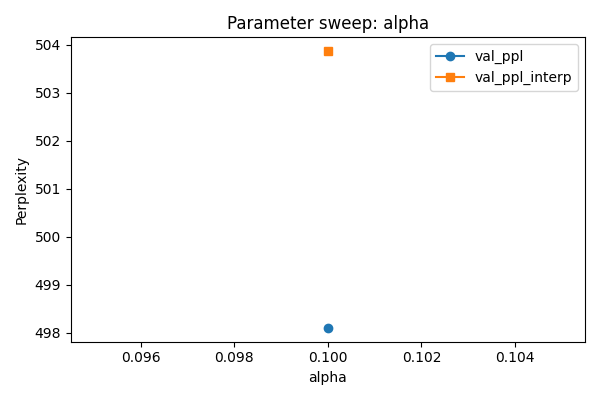

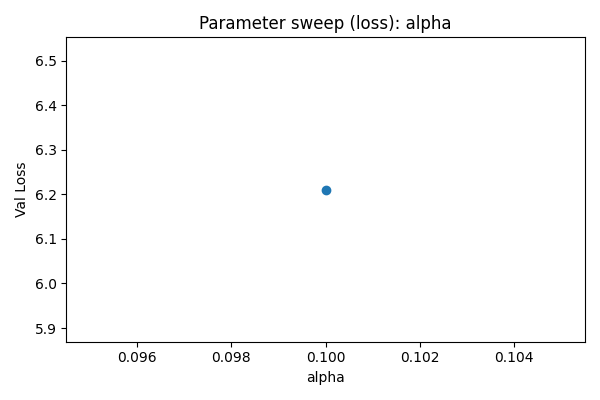

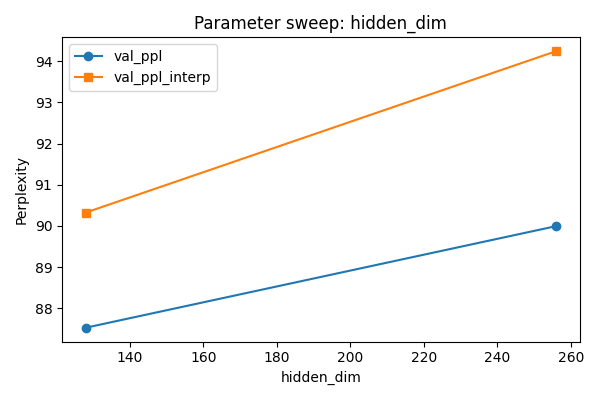

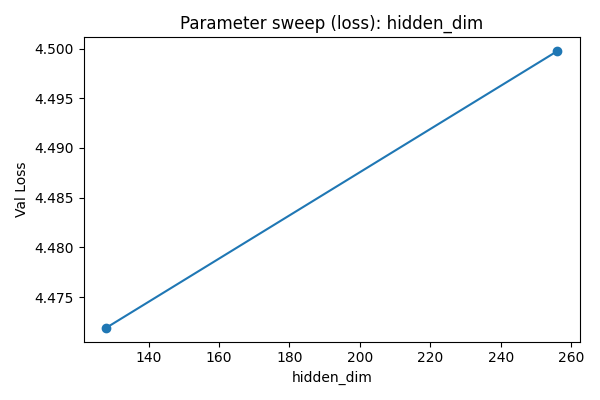

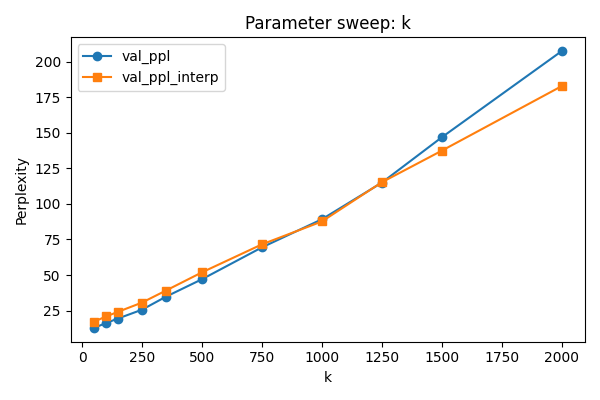

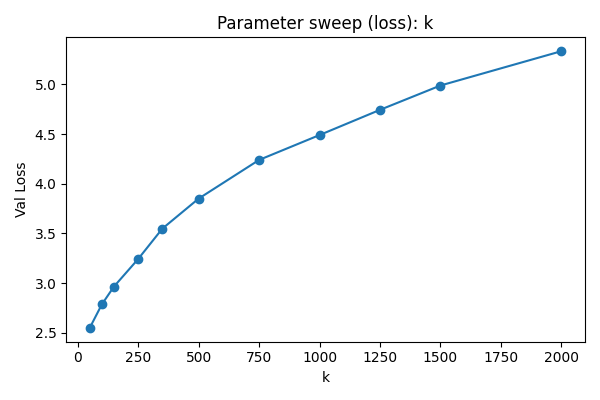

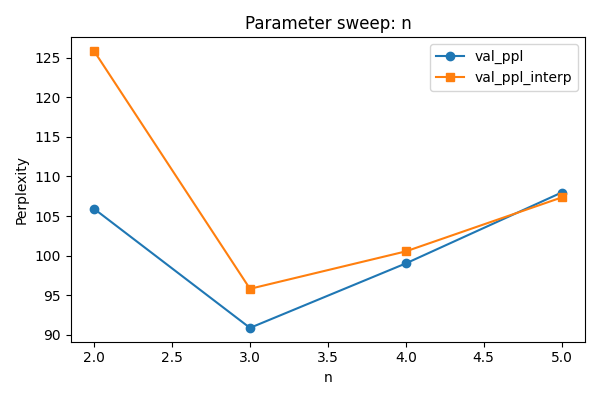

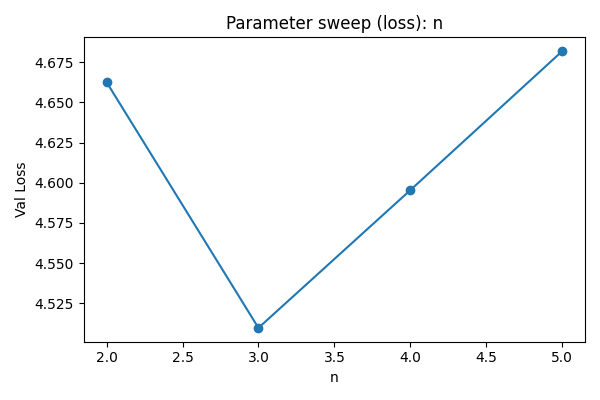

In [2]:
import os, glob, IPython.display as display

plot_dir = 'data/hyperparams/plots'
if not os.path.isdir(plot_dir):
    print(f'No plot directory found at {plot_dir}. Run plot_results() first.')
else:
    plot_files = sorted(glob.glob(os.path.join(plot_dir, '*.png')))
    if not plot_files:
        print('No plot images found. Ensure plot_results() has been executed.')
    else:
        print(f'Found {len(plot_files)} plot images:')
        for pf in plot_files:
            print(' -', pf)
        # Display
        for pf in plot_files:
            display.display(display.Image(filename=pf))